# FedProx + LADS: Lesion-Aware Difficulty Signaling
## FIXED & AUDITED VERSION — April 2026
---
**Fixes applied:**
1. ✅ evaluate_model_on_loader: safe record alignment via embedded metadata
2. ✅ Hardship evaluation throttled to every N rounds (configurable)
3. ✅ Memory guard on sliding-window inference with fallback
4. ✅ aggregate_state_dicts handles integer tensors (BatchNorm num_batches_tracked)
5. ✅ best_model stored with deep-copy to prevent reference aliasing
6. ✅ Cache versioning and invalidation warning
7. ✅ Full end-to-end modular structure with smoke test


## 1. Install dependencies

In [ ]:
!pip -q install monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 108.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports and runtime setup

In [ ]:
import os
import re
import gc
import json
import math
import copy
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F

from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    NormalizeIntensityd,
    ConcatItemsd,
    DeleteItemsd,
    CropForegroundd,
    SpatialPadd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandGaussianNoised,
    ToTensord,
)
from monai.data import Dataset, PersistentDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


device: cuda


## 3. Configuration

In [ ]:
# ===== paths =====
TRAIN_ROOT = Path("/content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData")
PARTITIONS_JSON = Path("/content/final_data_partitions.json")

STATS_CSV_CANDIDATES = [
    Path("master_lesion_stats.csv"),
    Path("/content/master_lesion_stats.csv"),
    Path("/content/sample_data/master_lesion_stats.csv"),
    Path("/content/drive/MyDrive/master_lesion_stats.csv"),
]

OUTPUT_DIR = Path("/content/drive/MyDrive/fets_lads_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_VERSION = "v4_gpu_fast"
CACHE_DIR = Path(f"/content/fets_lads_cache_{CACHE_VERSION}")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_DATA_ROOT = Path("/content/fets_local_cases")
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Cache dir: {CACHE_DIR}")
print(f"Local case mirror dir: {LOCAL_DATA_ROOT}")

# ===== experiment selection =====
EXPERIMENTS_TO_RUN = ["fedprox_lads"]
# To run full ablation: EXPERIMENTS_TO_RUN = ["fedprox_baseline", "fedprox_lft", "fedprox_lads"]

METHOD_PRESETS = {
    "fedavg_baseline": {
        "use_prox": False, "use_lft": False,
        "use_hardship_signal": False, "use_hardship_agg": False, "prox_mu": 0.0,
    },
    "fedprox_baseline": {
        "use_prox": True, "use_lft": False,
        "use_hardship_signal": False, "use_hardship_agg": False, "prox_mu": 0.01,
    },
    "fedprox_lft": {
        "use_prox": True, "use_lft": True,
        "use_hardship_signal": True, "use_hardship_agg": False, "prox_mu": 0.01,
    },
    "fedprox_lads": {
        "use_prox": True, "use_lft": True,
        "use_hardship_signal": True, "use_hardship_agg": True, "prox_mu": 0.01,
    },
}

# ===== data / loader =====
N_CLIENTS = 5
VAL_PER_CLIENT = 10

GPU_TOTAL_GB = 0.0
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    GPU_TOTAL_GB = props.total_memory / (1024 ** 3)

HIGH_VRAM = GPU_TOTAL_GB >= 30.0
TRAIN_BATCH_SIZE = 2 if HIGH_VRAM else 1
TRAIN_PATCHES_PER_CASE = 4
TRAIN_POS = 3
TRAIN_NEG = 1

EVAL_BATCH_SIZE = 1
NUM_WORKERS = 8 if HIGH_VRAM else 4
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None
USE_PERSISTENT_DATASET = False
MIRROR_CASES_TO_LOCAL = False

# ===== model / training =====
ROUNDS = 20
LOCAL_EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
ROI_SIZE = (96, 96, 96)
USE_AMP = torch.cuda.is_available()
USE_CHANNELS_LAST_3D = torch.cuda.is_available()

# ===== full-volume validation / test =====
SW_BATCH_SIZE = 4 if HIGH_VRAM else 2
SW_OVERLAP = 0.5

# ===== loss / improvement =====
LFT_ALPHA = 0.3
LFT_BETA = 0.7
LFT_GAMMA = 1.33
BASE_LFT_WEIGHT = 0.15
HARDSHIP_TO_LFT = 1.50

AGG_RHO = 0.60
HARDSHIP_CLIP = 0.50
AGG_MULTIPLIER_MIN = 0.80
AGG_MULTIPLIER_MAX = 1.60

# ===== evaluation throttles =====
HARDSHIP_EVAL_EVERY_N_ROUNDS = 5
FULL_VAL_EVERY_N_ROUNDS = 5
HARDSHIP_MAX_CASES_PER_CLIENT = 4
FAST_VAL_MAX_CASES_PER_CLIENT = 4
THRESHOLD = 0.5

print("EXPERIMENTS_TO_RUN =", EXPERIMENTS_TO_RUN)
print("OUTPUT_DIR =", OUTPUT_DIR)
print(f"GPU total memory: {GPU_TOTAL_GB:.1f} GB")
print(f"TRAIN_BATCH_SIZE={TRAIN_BATCH_SIZE} | NUM_WORKERS={NUM_WORKERS} | SW_BATCH_SIZE={SW_BATCH_SIZE}")
print(f"Hardship eval every {HARDSHIP_EVAL_EVERY_N_ROUNDS} rounds | full val every {FULL_VAL_EVERY_N_ROUNDS} rounds")


Cache dir: /content/fets_lads_cache_v4_gpu_fast
Local case mirror dir: /content/fets_local_cases
EXPERIMENTS_TO_RUN = ['fedprox_lads']
OUTPUT_DIR = /content/drive/MyDrive/fets_lads_outputs
GPU total memory: 22.0 GB
TRAIN_BATCH_SIZE=1 | NUM_WORKERS=4 | SW_BATCH_SIZE=2
Hardship eval every 5 rounds | full val every 5 rounds


## 4. Helper functions: stats loading, modality resolution, partitions

In [ ]:
SMALL_THRESH_CM3 = 30.0
MEDIUM_THRESH_CM3 = 100.0

def assign_group(v_cm3):
    v_cm3 = float(v_cm3)
    if v_cm3 < SMALL_THRESH_CM3:
        return "small"
    elif v_cm3 <= MEDIUM_THRESH_CM3:
        return "medium"
    return "large"

def pick_stats_csv(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find master_lesion_stats.csv. Checked:\n" +
        "\n".join(str(Path(p)) for p in candidates)
    )

def load_stats_df():
    stats_csv = pick_stats_csv(STATS_CSV_CANDIDATES)
    print("Using stats CSV:", stats_csv)
    df = pd.read_csv(stats_csv)

    if "case_id" not in df.columns:
        if "case_name" in df.columns:
            df["case_id"] = df["case_name"].astype(str).apply(lambda x: Path(x).name)
        elif "path" in df.columns:
            df["case_id"] = df["path"].astype(str).apply(lambda x: Path(x).name)
        elif "case" in df.columns:
            df["case_id"] = df["case"].astype(str)
        elif "subject_id" in df.columns:
            df["case_id"] = df["subject_id"].astype(str)
        else:
            raise ValueError("Could not infer case_id from stats CSV.")

    if "lesion_cm3" in df.columns:
        df["lesion_cm3"] = df["lesion_cm3"].astype(float)
    elif "lesion_volume_cm3" in df.columns:
        df["lesion_cm3"] = df["lesion_volume_cm3"].astype(float)
    elif "lesion_volume" in df.columns:
        df["lesion_cm3"] = df["lesion_volume"].astype(float) / 1000.0
    else:
        raise ValueError("Could not find lesion volume information in stats CSV.")

    df["size_group"] = df["lesion_cm3"].apply(assign_group)
    df["case_id"] = df["case_id"].astype(str)
    return df

stats_df = load_stats_df()
stats_index = {row["case_id"]: row for _, row in stats_df.iterrows()}

def modality_from_name(name):
    n = name.lower()
    if "seg" in n:
        return "seg"
    if "flair" in n:
        return "flair"
    if "t1ce" in n or "t1gd" in n:
        return "t1ce"
    if re.search(r"(^|[_\-.])t1([_\-.]|$)", n) and "t1ce" not in n and "t1gd" not in n:
        return "t1"
    if re.search(r"(^|[_\-.])t2([_\-.]|$)", n):
        return "t2"
    return None

MODALITY_ORDER = ["flair", "t1", "t1ce", "t2"]

def resolve_case_files(case_dir):
    case_dir = Path(case_dir)
    files = sorted(case_dir.glob("*.nii.gz"))
    if len(files) == 0:
        raise FileNotFoundError(f"No .nii.gz files found in {case_dir}")

    found = {}
    seg_path = None

    for f in files:
        key = modality_from_name(f.name)
        if key is None:
            continue
        if key == "seg":
            seg_path = str(f)
        else:
            found[key] = str(f)

    missing = [k for k in MODALITY_ORDER if k not in found]
    if seg_path is None or missing:
        raise RuntimeError(
            f"Case {case_dir.name} is missing expected files.\n"
            f"Missing modalities: {missing}\n"
            f"Seg found: {seg_path is not None}\n"
            f"Files present: {[f.name for f in files]}"
        )

    return {
        "case_name": case_dir.name,
        "flair": found["flair"],
        "t1": found["t1"],
        "t1ce": found["t1ce"],
        "t2": found["t2"],
        "label": seg_path,
        "case_path": str(case_dir),
    }

def attach_case_meta(case_dir):
    case_dir = Path(case_dir)
    name = case_dir.name
    row = stats_index.get(name, None)

    if row is not None:
        lesion_cm3 = float(row["lesion_cm3"])
        size_group = str(row["size_group"])
    else:
        seg_files = list(case_dir.glob("*seg*.nii.gz"))
        if len(seg_files) != 1:
            raise RuntimeError(f"Expected one seg file in {case_dir}, found {len(seg_files)}")
        lesion_cm3 = float((nib.load(str(seg_files[0])).get_fdata() > 0).sum()) / 1000.0
        size_group = assign_group(lesion_cm3)

    return {
        "case_path": case_dir,
        "case_name": name,
        "lesion_cm3": lesion_cm3,
        "size_group": size_group,
    }

# ---------- locked-box test metadata ----------
if not PARTITIONS_JSON.exists():
    raise FileNotFoundError(f"Partition metadata not found: {PARTITIONS_JSON}")

with open(PARTITIONS_JSON, "r") as fh:
    meta_lb = json.load(fh)

if "test_set_paths" not in meta_lb:
    raise KeyError("PARTITIONS_JSON must contain key 'test_set_paths'")

test_case_paths = [Path(p) for p in meta_lb["test_set_paths"]]
test_meta = [attach_case_meta(p) for p in test_case_paths]
test_meta_df = pd.DataFrame(test_meta)
print(f"Locked-box test set: {len(test_meta_df)} cases")
display(test_meta_df["size_group"].value_counts().rename_axis("size_group").to_frame("count"))

# ---------- reconstruct training/client pool ----------
if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f"TRAIN_ROOT not found: {TRAIN_ROOT}")

train_case_dirs = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
if len(train_case_dirs) == 0:
    raise RuntimeError(f"No case folders found under TRAIN_ROOT={TRAIN_ROOT}")

case_dir_by_id = {p.name: p for p in train_case_dirs}
train_df = stats_df[stats_df["case_id"].isin(case_dir_by_id.keys())].copy()
train_df["path"] = train_df["case_id"].map(case_dir_by_id)
train_df = train_df.dropna(subset=["path"]).copy()

if len(train_df) == 0:
    raise RuntimeError("No train cases matched between TRAIN_ROOT and master_lesion_stats.csv.")

def dirichlet_partition(df_in, num_clients=5, alpha=0.5):
    clients = {i: [] for i in range(num_clients)}
    for group in ["small", "medium", "large"]:
        group_df = df_in[df_in["size_group"] == group].sample(frac=1, random_state=SEED)
        if len(group_df) == 0:
            continue
        proportions = np.random.dirichlet([alpha] * num_clients)
        splits = (proportions * len(group_df)).astype(int)
        remainder = len(group_df) - splits.sum()
        for r in range(remainder):
            splits[r % num_clients] += 1
        start = 0
        for i in range(num_clients):
            end = start + splits[i]
            clients[i].extend(group_df.iloc[start:end]["path"].tolist())
            start = end
    return clients

def stratified_cap(paths, df_in, max_cases=80):
    client_df = df_in[df_in["path"].isin(paths)].copy()
    if len(client_df) <= max_cases:
        return client_df["path"].tolist()
    sampled = client_df.groupby("size_group", group_keys=False).apply(
        lambda x: x.sample(frac=max_cases / len(client_df), random_state=SEED)
    )
    sampled = sampled.drop_duplicates(subset=["path"])
    if len(sampled) > max_cases:
        sampled = sampled.sample(n=max_cases, random_state=SEED)
    return sampled["path"].tolist()

def make_client_splits(client_paths, val_per_client=10, seed=SEED):
    rng = random.Random(seed)
    train_meta_by_client = []
    val_meta_by_client = []
    for plist in client_paths:
        plist = list(plist)
        rng.shuffle(plist)
        n_val = min(val_per_client, max(1, len(plist) // 5))
        if n_val >= len(plist):
            n_val = max(1, len(plist) - 1)
        val_paths = plist[:n_val]
        train_paths = plist[n_val:]
        train_meta_by_client.append([attach_case_meta(p) for p in train_paths])
        val_meta_by_client.append([attach_case_meta(p) for p in val_paths])
    return train_meta_by_client, val_meta_by_client

np.random.seed(SEED)
clients = dirichlet_partition(train_df, num_clients=N_CLIENTS, alpha=0.5)
for i in range(N_CLIENTS):
    clients[i] = stratified_cap(clients[i], train_df, max_cases=80)

client_case_paths = [clients[i] for i in range(N_CLIENTS)]
train_meta_by_client, val_meta_by_client = make_client_splits(client_case_paths, VAL_PER_CLIENT, SEED)

print("Per-client split summary:")
summary_rows = []
for i in range(N_CLIENTS):
    train_counts = pd.Series([m["size_group"] for m in train_meta_by_client[i]]).value_counts()
    val_counts = pd.Series([m["size_group"] for m in val_meta_by_client[i]]).value_counts()
    row = {
        "client": i,
        "train_total": len(train_meta_by_client[i]),
        "val_total": len(val_meta_by_client[i]),
        "train_small": int(train_counts.get("small", 0)),
        "train_medium": int(train_counts.get("medium", 0)),
        "train_large": int(train_counts.get("large", 0)),
        "val_small": int(val_counts.get("small", 0)),
        "val_medium": int(val_counts.get("medium", 0)),
        "val_large": int(val_counts.get("large", 0)),
    }
    summary_rows.append(row)

split_summary_df = pd.DataFrame(summary_rows)
display(split_summary_df)


Using stats CSV: master_lesion_stats.csv
Locked-box test set: 90 cases


,count
size_group,
small,30
medium,30
large,30


Per-client split summary:


,client,train_total,val_total,train_small,train_medium,train_large,val_small,val_medium,val_large
0,0,70,10,7,0,63,0,0,10
1,1,70,10,12,53,5,0,9,1
2,2,70,10,2,9,59,0,0,10
3,3,45,10,0,32,13,0,4,6
4,4,69,10,10,15,44,2,4,4


In [ ]:
# # ===== optional local mirroring + cheap eval subsets =====
# import shutil


# def _mirror_one_case(case_path, local_root=LOCAL_DATA_ROOT):
#     case_path = Path(case_path)
#     dst_dir = local_root / case_path.name
#     dst_dir.mkdir(parents=True, exist_ok=True)
#     for src in case_path.glob("*.nii.gz"):
#         dst = dst_dir / src.name
#         if not dst.exists() or dst.stat().st_size != src.stat().st_size:
#             shutil.copy2(src, dst)
#     return dst_dir


# def _remap_meta_rows_to_local(meta_rows):
#     out = []
#     for meta in meta_rows:
#         new_meta = dict(meta)
#         new_meta["case_path"] = _mirror_one_case(meta["case_path"])
#         out.append(new_meta)
#     return out

# if MIRROR_CASES_TO_LOCAL:
#     print("Mirroring selected train/val/test cases to local SSD (first run only)...")
#     train_meta_by_client = [_remap_meta_rows_to_local(rows) for rows in train_meta_by_client]
#     val_meta_by_client = [_remap_meta_rows_to_local(rows) for rows in val_meta_by_client]
#     test_meta = _remap_meta_rows_to_local(test_meta)
#     print("Local mirroring done.")


# def make_small_priority_subset(meta_rows, max_cases=4, seed=SEED):
#     if len(meta_rows) <= max_cases:
#         return list(meta_rows)
#     rng = random.Random(seed)
#     small = [r for r in meta_rows if r["size_group"] == "small"]
#     rest = [r for r in meta_rows if r["size_group"] != "small"]
#     rng.shuffle(small)
#     rng.shuffle(rest)
#     take_small = min(len(small), max_cases)
#     subset = small[:take_small]
#     remaining = max_cases - len(subset)
#     if remaining > 0:
#         subset.extend(rest[:remaining])
#     return subset

# hardship_meta_by_client = [
#     make_small_priority_subset(rows, max_cases=HARDSHIP_MAX_CASES_PER_CLIENT, seed=SEED + i)
#     for i, rows in enumerate(val_meta_by_client)
# ]
# fast_val_meta_by_client = [
#     make_small_priority_subset(rows, max_cases=FAST_VAL_MAX_CASES_PER_CLIENT, seed=SEED + 100 + i)
#     for i, rows in enumerate(val_meta_by_client)
# ]

# for i in range(N_CLIENTS):
#     print(f"Client {i}: hardship subset={len(hardship_meta_by_client[i])} | fast val subset={len(fast_val_meta_by_client[i])}")


In [ ]:
# ===== build hardship / fast-val metadata subsets =====

# safe defaults if not already defined earlier
if "MIRROR_CASES_TO_LOCAL" not in globals():
    MIRROR_CASES_TO_LOCAL = False

if "LOCAL_DATA_ROOT" not in globals():
    LOCAL_DATA_ROOT = Path("/content/fets_local")

if "HARDSHIP_MAX_CASES_PER_CLIENT" not in globals():
    HARDSHIP_MAX_CASES_PER_CLIENT = 4

if "FAST_VAL_MAX_CASES_PER_CLIENT" not in globals():
    FAST_VAL_MAX_CASES_PER_CLIENT = 4

import shutil
import random

def _mirror_one_case(case_path, local_root=LOCAL_DATA_ROOT):
    case_path = Path(case_path)
    dst_dir = local_root / case_path.name
    dst_dir.mkdir(parents=True, exist_ok=True)

    for src in case_path.glob("*.nii.gz"):
        dst = dst_dir / src.name
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            shutil.copy2(src, dst)

    return dst_dir

def _remap_meta_rows_to_local(meta_rows):
    out = []
    for meta in meta_rows:
        new_meta = dict(meta)
        new_meta["case_path"] = _mirror_one_case(meta["case_path"])
        out.append(new_meta)
    return out

# optional local mirroring
if MIRROR_CASES_TO_LOCAL:
    print("Mirroring selected train/val/test cases to local SSD (first run only)...")
    train_meta_by_client = [_remap_meta_rows_to_local(rows) for rows in train_meta_by_client]
    val_meta_by_client   = [_remap_meta_rows_to_local(rows) for rows in val_meta_by_client]
    test_meta            = _remap_meta_rows_to_local(test_meta)
    print("Local mirroring done.")

def make_small_priority_subset(meta_rows, max_cases=4, seed=42):
    meta_rows = list(meta_rows)
    if len(meta_rows) <= max_cases:
        return list(meta_rows)

    rng = random.Random(seed)

    small = [r for r in meta_rows if str(r["size_group"]).lower() == "small"]
    rest  = [r for r in meta_rows if str(r["size_group"]).lower() != "small"]

    rng.shuffle(small)
    rng.shuffle(rest)

    take_small = min(len(small), max_cases)
    subset = small[:take_small]

    remaining = max_cases - len(subset)
    if remaining > 0:
        subset.extend(rest[:remaining])

    return subset

hardship_meta_by_client = [
    make_small_priority_subset(rows, max_cases=HARDSHIP_MAX_CASES_PER_CLIENT, seed=SEED + i)
    for i, rows in enumerate(val_meta_by_client)
]

fast_val_meta_by_client = [
    make_small_priority_subset(rows, max_cases=FAST_VAL_MAX_CASES_PER_CLIENT, seed=SEED + 100 + i)
    for i, rows in enumerate(val_meta_by_client)
]

for i in range(N_CLIENTS):
    print(
        f"Client {i}: "
        f"train={len(train_meta_by_client[i])} | "
        f"val={len(val_meta_by_client[i])} | "
        f"hardship={len(hardship_meta_by_client[i])} | "
        f"fast_val={len(fast_val_meta_by_client[i])}"
    )

Client 0: train=70 | val=10 | hardship=4 | fast_val=4
Client 1: train=70 | val=10 | hardship=4 | fast_val=4
Client 2: train=70 | val=10 | hardship=4 | fast_val=4
Client 3: train=45 | val=10 | hardship=4 | fast_val=4
Client 4: train=69 | val=10 | hardship=4 | fast_val=4


## 5. MONAI records and transforms

Training uses positive/negative patch sampling — **no center crop** during training.
Evaluation uses full foreground-cropped volume + sliding-window inference — **no center crop** during evaluation either.

In [ ]:
def meta_to_records(meta_rows):
    records = []
    for meta in meta_rows:
        rec = resolve_case_files(meta["case_path"])
        rec["case_name"] = str(meta["case_name"])
        rec["size_group"] = str(meta["size_group"])
        rec["lesion_cm3"] = float(meta["lesion_cm3"])
        records.append(rec)
    return records

train_records_by_client = [meta_to_records(x) for x in train_meta_by_client]
val_records_by_client   = [meta_to_records(x) for x in val_meta_by_client]
hardship_records_by_client = [meta_to_records(x) for x in hardship_meta_by_client]
fast_val_records_by_client = [meta_to_records(x) for x in fast_val_meta_by_client]
test_records = meta_to_records(test_meta)

MOD_KEYS = ["flair", "t1", "t1ce", "t2"]

train_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ["label"]),
    EnsureChannelFirstd(keys=MOD_KEYS + ["label"]),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name="image", dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=ROI_SIZE),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=TRAIN_POS,
        neg=TRAIN_NEG,
        num_samples=TRAIN_PATCHES_PER_CASE,
        image_key="image",
        image_threshold=0.0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=["image"], prob=0.10, mean=0.0, std=0.01),
    ToTensord(keys=["image", "label"]),
])

eval_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ["label"]),
    EnsureChannelFirstd(keys=MOD_KEYS + ["label"]),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name="image", dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=ROI_SIZE),
    ToTensord(keys=["image", "label"]),
])

def build_dataset(records, transform, cache_subdir):
    if USE_PERSISTENT_DATASET:
        cache_dir = CACHE_DIR / cache_subdir
        cache_dir.mkdir(parents=True, exist_ok=True)
        return PersistentDataset(data=records, transform=transform, cache_dir=str(cache_dir))
    return Dataset(data=records, transform=transform)

def build_loader(dataset, batch_size, shuffle):
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(**kwargs)

train_datasets, val_datasets = [], []
train_loaders, val_loaders   = [], []
hardship_loaders, fast_val_loaders = [], []

for i in range(N_CLIENTS):
    train_ds = build_dataset(train_records_by_client[i], train_transforms, f"train_client_{i}")
    val_ds   = build_dataset(val_records_by_client[i],   eval_transforms,  f"val_client_{i}")
    hardship_ds = build_dataset(hardship_records_by_client[i], eval_transforms, f"hardship_client_{i}")
    fast_val_ds = build_dataset(fast_val_records_by_client[i], eval_transforms, f"fast_val_client_{i}")

    train_datasets.append(train_ds)
    val_datasets.append(val_ds)
    train_loaders.append(build_loader(train_ds, TRAIN_BATCH_SIZE, shuffle=True))
    val_loaders.append(build_loader(val_ds, EVAL_BATCH_SIZE, shuffle=False))
    hardship_loaders.append(build_loader(hardship_ds, EVAL_BATCH_SIZE, shuffle=False))
    fast_val_loaders.append(build_loader(fast_val_ds, EVAL_BATCH_SIZE, shuffle=False))

test_dataset = build_dataset(test_records, eval_transforms, "locked_box_test")
test_loader  = build_loader(test_dataset, EVAL_BATCH_SIZE, shuffle=False)

print("Built train/val/test loaders.")
print(f"Train loader batch_size={TRAIN_BATCH_SIZE} | patches/case={TRAIN_PATCHES_PER_CASE}")


Built train/val/test loaders.
Train loader batch_size=1 | patches/case=4


## 6. Model definition

In [ ]:
def get_model():
    model = UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=1,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    ).to(device)
    if USE_CHANNELS_LAST_3D:
        model = model.to(memory_format=torch.channels_last_3d)
    return model

def flatten_train_batch(tensor):
    """Handle MONAI multi-sample crops: [B,N,C,H,W,D] -> [B*N,C,H,W,D]"""
    if tensor.ndim == 6:
        b, n, c, h, w, d = tensor.shape
        return tensor.reshape(b * n, c, h, w, d)
    if tensor.ndim == 5:
        return tensor
    raise ValueError(f"Unexpected tensor shape: {tuple(tensor.shape)}")

def move_image_to_device(x):
    x = x.to(device, non_blocking=True)
    if USE_CHANNELS_LAST_3D:
        x = x.contiguous(memory_format=torch.channels_last_3d)
    return x


## 7. Shape and forward-pass smoke test

In [ ]:
sample_batch = next(iter(train_loaders[0]))
x = flatten_train_batch(sample_batch["image"])
y = flatten_train_batch(sample_batch["label"])

print("flattened train batch image shape:", tuple(x.shape))
print("flattened train batch label shape:", tuple(y.shape))
assert x.ndim == 5 and x.shape[1] == 4, f"Expected [B,4,H,W,D], got {tuple(x.shape)}"
assert y.ndim == 5 and y.shape[1] == 1, f"Expected [B,1,H,W,D], got {tuple(y.shape)}"

positive_patches = int((y.view(y.shape[0], -1).sum(dim=1) > 0).sum().item())
print(f"tumor-positive patches in sampled training batch: {positive_patches}/{y.shape[0]}")
assert positive_patches > 0, "Training crop smoke test found zero tumor-positive patches."

val_batch = next(iter(val_loaders[0]))
vx = val_batch["image"]
vy = val_batch["label"]
print("validation image shape:", tuple(vx.shape))
assert vx.ndim == 5 and vx.shape[1] == 4

smoke_model = get_model()
smoke_model.eval()

with torch.inference_mode():
    x_dev  = move_image_to_device(x)
    vx_dev = move_image_to_device(vx)
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        logits_patch = smoke_model(x_dev)
        logits_sw = sliding_window_inference(
            inputs=vx_dev, roi_size=ROI_SIZE,
            sw_batch_size=SW_BATCH_SIZE, predictor=smoke_model,
            overlap=SW_OVERLAP, mode="gaussian", sw_device=device, device=device,
        )

assert logits_patch.shape[1] == 1
assert logits_sw.shape[1] == 1
print("✅ Smoke test passed.")
del smoke_model


flattened train batch image shape: (4, 4, 96, 96, 96)
flattened train batch label shape: (4, 1, 96, 96, 96)
tumor-positive patches in sampled training batch: 4/4
validation image shape: (1, 4, 143, 167, 141)
✅ Smoke test passed.


## 8. Losses, metrics, and difficulty signaling

In [ ]:
dice_loss_fn = DiceLoss(sigmoid=True)

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=1.33, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, target):
        probs  = torch.sigmoid(logits)
        target = target.float()
        dims   = tuple(range(2, probs.ndim))
        tp = (probs * target).sum(dim=dims)
        fp = (probs * (1.0 - target)).sum(dim=dims)
        fn = ((1.0 - probs) * target).sum(dim=dims)
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return torch.pow((1.0 - tversky), self.gamma).mean()

focal_tversky_loss = FocalTverskyLoss(alpha=LFT_ALPHA, beta=LFT_BETA, gamma=LFT_GAMMA)

def hard_dice_from_logits(logits, target, threshold=THRESHOLD, eps=1e-8):
    probs = torch.sigmoid(logits)
    pred = (probs > threshold).float()
    target = target.float()
    inter = (pred * target).sum().item()
    denom = pred.sum().item() + target.sum().item() + eps
    return float((2.0 * inter) / denom)

@torch.inference_mode()
def predict_full_volume_logits(model, image, sw_batch_size=None):
    model.eval()
    sw_bs = SW_BATCH_SIZE if sw_batch_size is None else sw_batch_size
    try:
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            return sliding_window_inference(
                inputs=image,
                roi_size=ROI_SIZE,
                sw_batch_size=sw_bs,
                predictor=model,
                overlap=SW_OVERLAP,
                mode="gaussian",
                sw_device=device,
                device=device,
            )
    except RuntimeError as e:
        if "out of memory" in str(e).lower() and sw_bs > 1:
            torch.cuda.empty_cache()
            return sliding_window_inference(
                inputs=image,
                roi_size=ROI_SIZE,
                sw_batch_size=1,
                predictor=model,
                overlap=SW_OVERLAP,
                mode="gaussian",
                sw_device=device,
                device=device,
            )
        raise

@torch.inference_mode()
def evaluate_model_on_loader(model, loader, loader_records, sw_batch_size=None):
    assert len(loader.dataset) == len(loader_records), (
        f"Record/dataset mismatch: {len(loader.dataset)} vs {len(loader_records)}."
    )

    model.eval()
    all_scores = []
    by_group = defaultdict(list)

    for idx, batch in enumerate(loader):
        rec = loader_records[idx]
        x = move_image_to_device(batch["image"])
        y = (batch["label"].to(device, non_blocking=True) > 0).float()
        logits = predict_full_volume_logits(model, x, sw_batch_size=sw_batch_size)
        score = hard_dice_from_logits(logits, y)
        all_scores.append(score)
        by_group[rec["size_group"]].append(score)

    out = {
        "mean_dice": float(np.mean(all_scores)) if all_scores else 0.0,
        "small_dice": float(np.mean(by_group["small"])) if by_group["small"] else float("nan"),
        "medium_dice": float(np.mean(by_group["medium"])) if by_group["medium"] else float("nan"),
        "large_dice": float(np.mean(by_group["large"])) if by_group["large"] else float("nan"),
        "n_cases": len(all_scores),
    }
    out["fairness_gap"] = float(out["mean_dice"] - min(all_scores)) if all_scores else float("nan")
    out["small_lesion_gap"] = float(out["mean_dice"] - out["small_dice"]) if not math.isnan(out["small_dice"]) else float("nan")
    return out

@torch.inference_mode()
def compute_client_hardship(model, loader, loader_records):
    metrics = evaluate_model_on_loader(model, loader, loader_records, sw_batch_size=SW_BATCH_SIZE)
    frac_small = float(np.mean([1.0 if r["size_group"] == "small" else 0.0 for r in loader_records]))
    overall = float(metrics["mean_dice"])
    small = float(metrics["small_dice"]) if not math.isnan(metrics["small_dice"]) else overall
    gap = max(0.0, overall - small)
    hardship = min(frac_small * gap, HARDSHIP_CLIP)
    metrics.update({"frac_small": frac_small, "hardship_gap": gap, "hardship": hardship})
    return metrics

def make_local_loss(logits, target, lambda_lft):
    return dice_loss_fn(logits, target) + lambda_lft * focal_tversky_loss(logits, target)


def client_train_weight(n_cases, hardship, use_hardship_agg):
    if not use_hardship_agg:
        return float(n_cases)
    multiplier = max(AGG_MULTIPLIER_MIN, min(AGG_MULTIPLIER_MAX, 1.0 + AGG_RHO * hardship))
    return float(n_cases) * float(multiplier)


## 9. Local training and aggregation

In [ ]:
def train_local_client(model, global_reference_model, loader, optimizer,
                       local_epochs, prox_mu=0.0, lambda_lft=0.0):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    ref_params = None
    if prox_mu > 0.0:
        ref_params = {name: p.detach().clone() for name, p in global_reference_model.named_parameters()}

    epoch_logs = []

    for epoch in range(local_epochs):
        batch_losses, batch_pos_rates = [], []

        for batch in loader:
            x = move_image_to_device(flatten_train_batch(batch["image"]))
            y = (flatten_train_batch(batch["label"]).to(device, non_blocking=True) > 0).float()

            batch_pos_rates.append(
                float((y.view(y.shape[0], -1).sum(dim=1) > 0).float().mean().item())
            )

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss = make_local_loss(logits, y, lambda_lft=lambda_lft)
                if prox_mu > 0.0:
                    prox_term = sum(torch.sum((p - ref_params[name]) ** 2) for name, p in model.named_parameters())
                    loss = loss + 0.5 * prox_mu * prox_term

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            batch_losses.append(float(loss.detach().item()))

        epoch_logs.append({
            "mean_loss": float(np.mean(batch_losses)) if batch_losses else float("nan"),
            "mean_positive_patch_rate": float(np.mean(batch_pos_rates)) if batch_pos_rates else float("nan"),
        })

    return epoch_logs


def aggregate_state_dicts(state_dicts, weights):
    total_weight = float(sum(weights))
    if total_weight <= 0:
        raise ValueError("Aggregation weights must sum to a positive value.")

    agg = copy.deepcopy(state_dicts[0])

    for key in agg.keys():
        original_dtype = state_dicts[0][key].dtype
        is_integer = not torch.is_floating_point(state_dicts[0][key])

        stacked = None
        for sd, w in zip(state_dicts, weights):
            tensor = sd[key].float() * (w / total_weight)
            stacked = tensor if stacked is None else stacked + tensor

        agg[key] = stacked.round().to(original_dtype) if is_integer else stacked.to(original_dtype)

    return agg


## 10. Experiment runner

In [ ]:
def evaluate_global_on_all_clients(model, use_fast_subset=False):
    client_metrics = []
    if use_fast_subset:
        eval_loaders = fast_val_loaders
        eval_records = fast_val_records_by_client
    else:
        eval_loaders = val_loaders
        eval_records = val_records_by_client

    for i in range(N_CLIENTS):
        m = evaluate_model_on_loader(model, eval_loaders[i], eval_records[i], sw_batch_size=SW_BATCH_SIZE)
        m["client_id"] = i
        client_metrics.append(m)

    df = pd.DataFrame(client_metrics)
    return {
        "val_mean_dice": float(df["mean_dice"].mean()),
        "val_worst_client_dice": float(df["mean_dice"].min()),
        "val_small_dice_mean": float(df["small_dice"].dropna().mean()) if df["small_dice"].notna().any() else float("nan"),
        "val_medium_dice_mean": float(df["medium_dice"].dropna().mean()) if df["medium_dice"].notna().any() else float("nan"),
        "val_large_dice_mean": float(df["large_dice"].dropna().mean()) if df["large_dice"].notna().any() else float("nan"),
        "val_fairness_gap": float(df["mean_dice"].mean() - df["mean_dice"].min()),
        "client_metrics_df": df,
    }


def run_federated_experiment(method_name):
    if method_name not in METHOD_PRESETS:
        raise ValueError(f"Unknown method: {method_name}")

    cfg = METHOD_PRESETS[method_name]
    print("=" * 80)
    print("Running", method_name.upper())
    print("=" * 80)
    print(cfg)

    exp_dir  = OUTPUT_DIR / method_name
    ckpt_dir = exp_dir / "checkpoints"
    exp_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    global_model = get_model()

    # keep these only in RAM; do NOT stuff them into every checkpoint
    history_rows = []
    difficulty_rows_all = []

    best_val_so_far = -1.0
    best_round_so_far = -1

    cached_hardship_metrics = [{
        "mean_dice": float("nan"),
        "small_dice": float("nan"),
        "frac_small": 0.0,
        "hardship_gap": 0.0,
        "hardship": 0.0,
    } for _ in range(N_CLIENTS)]
    cached_val_summary = None

    for rnd in range(1, ROUNDS + 1):
        print(f"\nRound {rnd}/{ROUNDS}")
        local_state_dicts = []
        agg_weights = []
        round_difficulty_rows = []

        should_eval_hardship = (
            cfg["use_hardship_signal"] and
            (rnd == 1 or rnd % HARDSHIP_EVAL_EVERY_N_ROUNDS == 0)
        )

        for client_id in range(N_CLIENTS):
            print(f"  Client {client_id} ...", end=" ")

            if should_eval_hardship:
                cached_hardship_metrics[client_id] = compute_client_hardship(
                    global_model,
                    hardship_loaders[client_id],
                    hardship_records_by_client[client_id]
                )

            hardship_metrics = cached_hardship_metrics[client_id]
            hardship = float(hardship_metrics["hardship"])
            lambda_lft = BASE_LFT_WEIGHT + HARDSHIP_TO_LFT * hardship if cfg["use_lft"] else 0.0

            local_model = get_model()
            local_model.load_state_dict(global_model.state_dict())

            optimizer = torch.optim.AdamW(
                local_model.parameters(),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )

            epoch_logs = train_local_client(
                model=local_model,
                global_reference_model=global_model,
                loader=train_loaders[client_id],
                optimizer=optimizer,
                local_epochs=LOCAL_EPOCHS,
                prox_mu=cfg["prox_mu"] if cfg["use_prox"] else 0.0,
                lambda_lft=lambda_lft,
            )

            n_train = len(train_records_by_client[client_id])
            train_weight = client_train_weight(
                n_train,
                hardship,
                cfg["use_hardship_agg"]
            )

            local_state_dicts.append({
                k: v.detach().cpu().clone()
                for k, v in local_model.state_dict().items()
            })
            agg_weights.append(train_weight)

            last_epoch = epoch_logs[-1] if epoch_logs else {
                "mean_loss": float("nan"),
                "mean_positive_patch_rate": float("nan")
            }

            row = {
                "round": rnd,
                "client_id": client_id,
                "lambda_lft": lambda_lft,
                "agg_weight": train_weight,
                "prox_mu": cfg["prox_mu"] if cfg["use_prox"] else 0.0,
                "last_local_epoch_loss": float(last_epoch["mean_loss"]),
                "last_epoch_positive_patch_rate": float(last_epoch["mean_positive_patch_rate"]),
                "hardship_eval_this_round": should_eval_hardship,
            }
            row.update(hardship_metrics)
            round_difficulty_rows.append(row)

            print(
                f"hardship={hardship:.4f} | lambda_lft={lambda_lft:.4f} | "
                f"agg_w={train_weight:.2f} | patch_pos={row['last_epoch_positive_patch_rate']:.2f}"
            )

            del local_model, optimizer

        global_state = aggregate_state_dicts(local_state_dicts, agg_weights)
        global_model.load_state_dict(global_state)

        should_full_eval = (
            rnd == 1 or
            rnd % FULL_VAL_EVERY_N_ROUNDS == 0 or
            rnd == ROUNDS
        )

        if should_full_eval or cached_val_summary is None:
            val_summary = evaluate_global_on_all_clients(global_model, use_fast_subset=False)
            val_summary["val_eval_mode"] = "full"
            cached_val_summary = val_summary
        else:
            val_summary = evaluate_global_on_all_clients(global_model, use_fast_subset=True)
            val_summary["val_eval_mode"] = "fast_subset"

        round_row = {
            "round": rnd,
            "val_mean_dice": val_summary["val_mean_dice"],
            "val_worst_client_dice": val_summary["val_worst_client_dice"],
            "val_small_dice_mean": val_summary["val_small_dice_mean"],
            "val_medium_dice_mean": val_summary["val_medium_dice_mean"],
            "val_large_dice_mean": val_summary["val_large_dice_mean"],
            "val_fairness_gap": val_summary["val_fairness_gap"],
            "val_eval_mode": val_summary["val_eval_mode"],
        }

        history_rows.append(round_row)
        difficulty_rows_all.extend(round_difficulty_rows)

        print(
            f"  round summary [{round_row['val_eval_mode']}] | "
            f"mean={round_row['val_mean_dice']:.4f} | "
            f"worst_client={round_row['val_worst_client_dice']:.4f} | "
            f"small={round_row['val_small_dice_mean']:.4f} | "
            f"fairness_gap={round_row['val_fairness_gap']:.4f}"
        )

        # keep checkpoints small: model + minimal metadata only
        ckpt_payload = {
            "round": rnd,
            "model_state": global_model.state_dict(),
            "method_name": method_name,
            "config": cfg,
            "val_mean_dice": float(round_row["val_mean_dice"]),
            "val_eval_mode": round_row["val_eval_mode"],
        }

        # overwrite last checkpoint each round
        torch.save(ckpt_payload, ckpt_dir / f"{method_name}_last.pt")

        # save best checkpoint only when FULL validation improves
        if round_row["val_eval_mode"] == "full" and round_row["val_mean_dice"] >= best_val_so_far:
            best_val_so_far = float(round_row["val_mean_dice"])
            best_round_so_far = rnd
            torch.save(ckpt_payload, ckpt_dir / f"{method_name}_best.pt")

    history_df = pd.DataFrame(history_rows)
    difficulty_df = pd.DataFrame(difficulty_rows_all)

    scored_df = history_df[history_df["val_eval_mode"] == "full"].copy()
    if len(scored_df) == 0:
        scored_df = history_df.copy()

    best_idx = scored_df["val_mean_dice"].idxmax()
    best_round = int(history_df.loc[best_idx, "round"])

    best_ckpt = torch.load(ckpt_dir / f"{method_name}_best.pt", map_location=device)

    best_model = get_model()
    best_model.load_state_dict(best_ckpt["model_state"])

    test_metrics = evaluate_model_on_loader(
        best_model,
        test_loader,
        test_records,
        sw_batch_size=SW_BATCH_SIZE
    )

    history_df.to_csv(exp_dir / f"{method_name}_history.csv", index=False)
    difficulty_df.to_csv(exp_dir / f"{method_name}_difficulty_history.csv", index=False)
    pd.DataFrame([test_metrics]).to_csv(
        exp_dir / f"{method_name}_locked_box_test_metrics.csv",
        index=False
    )

    print("\nBest round:", best_round)
    print("Locked-box test:", test_metrics)

    return {
        "method_name": method_name,
        "config": cfg,
        "history_df": history_df,
        "difficulty_df": difficulty_df,
        "best_round": best_round,
        "best_val_mean_dice": float(history_df.loc[best_idx, "val_mean_dice"]),
        "best_model": copy.deepcopy(best_model),
        "test_metrics": test_metrics,
    }


## 11. Run selected experiments

In [ ]:
results = {}
for method_name in EXPERIMENTS_TO_RUN:
    results[method_name] = run_federated_experiment(method_name)

print("\nFinished experiments:")
for k, v in results.items():
    print(
        f"{k}: best_round={v['best_round']} | "
        f"best_val_mean={v['best_val_mean_dice']:.4f} | "
        f"test_mean={v['test_metrics']['mean_dice']:.4f} | "
        f"test_small={v['test_metrics'].get('small_dice', float('nan')):.4f}"
    )


Running FEDPROX_LADS
{'use_prox': True, 'use_lft': True, 'use_hardship_signal': True, 'use_hardship_agg': True, 'prox_mu': 0.01}

Round 1/20
  Client 0 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=1.00
  Client 1 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=0.98
  Client 2 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=1.00
  Client 3 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=45.00 | patch_pos=0.99
  Client 4 ... hardship=0.0142 | lambda_lft=0.1713 | agg_w=69.59 | patch_pos=1.00
  round summary [full] | mean=0.1350 | worst_client=0.0702 | small=0.0276 | fairness_gap=0.0648

Round 2/20
  Client 0 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=0.99
  Client 1 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=0.99
  Client 2 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=70.00 | patch_pos=1.00
  Client 3 ... hardship=0.0000 | lambda_lft=0.1500 | agg_w=45.00 | patch_pos=0.99
  Client 4 ..

## 12. Training curves

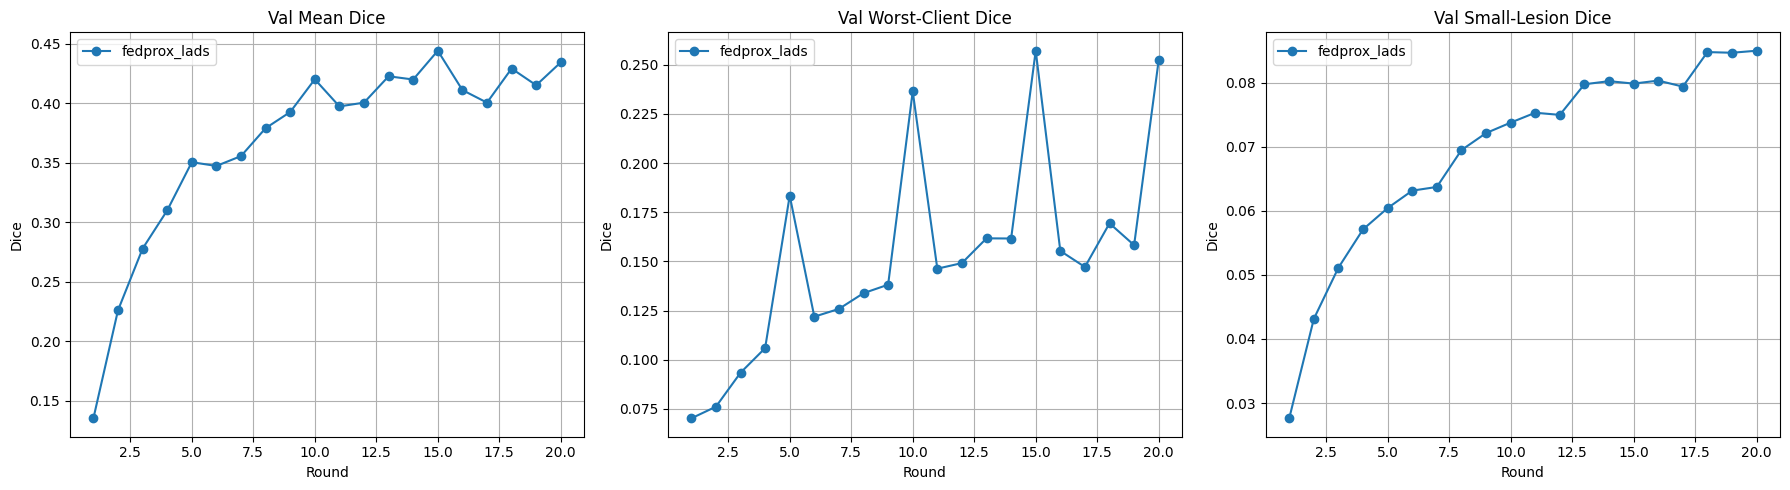

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for method_name, out in results.items():
    df = out["history_df"]
    axes[0].plot(df["round"], df["val_mean_dice"],         marker="o", label=method_name)
    axes[1].plot(df["round"], df["val_worst_client_dice"], marker="o", label=method_name)
    axes[2].plot(df["round"], df["val_small_dice_mean"],   marker="o", label=method_name)

for ax, title in zip(axes, ["Val Mean Dice", "Val Worst-Client Dice", "Val Small-Lesion Dice"]):
    ax.set_xlabel("Round"); ax.set_ylabel("Dice")
    ax.set_title(title); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Difficulty signal inspection

fedprox_lads


,frac_small,hardship,lambda_lft,agg_weight
client_id,,,,
0,0.0,0.0000,0.1500,70.0000
1,0.0,0.0000,0.1500,70.0000
2,0.0,0.0000,0.1500,70.0000
3,0.0,0.0000,0.1500,45.0000
4,0.5,0.0864,0.2795,72.5749


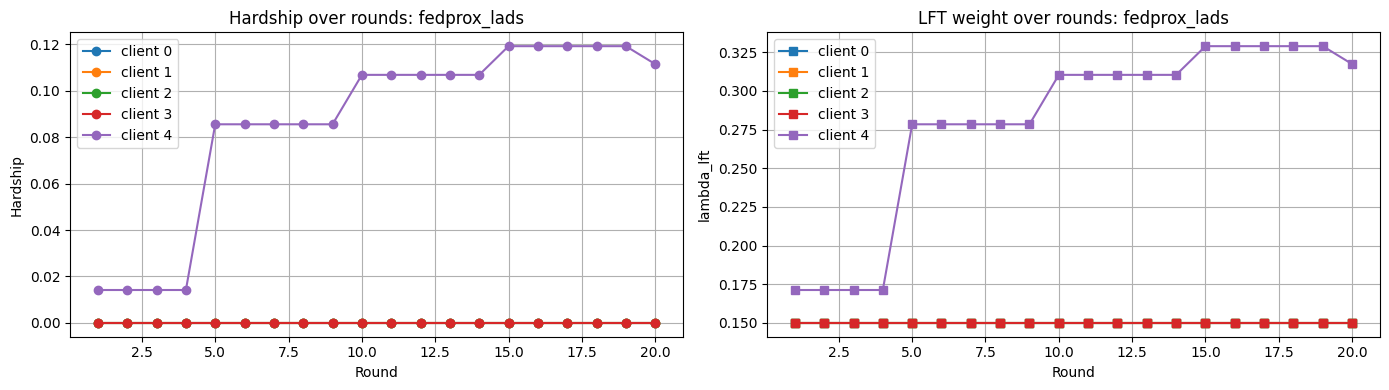

In [ ]:
for method_name, out in results.items():
    diff_df = out["difficulty_df"]
    if diff_df.empty:
        continue

    print("=" * 80)
    print(method_name)
    print("=" * 80)
    display(
        diff_df.groupby("client_id")[["frac_small", "hardship", "lambda_lft", "agg_weight"]]
        .mean().round(4)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for cid in sorted(diff_df["client_id"].unique()):
        sub = diff_df[diff_df["client_id"] == cid]
        axes[0].plot(sub["round"], sub["hardship"],   marker="o", label=f"client {cid}")
        axes[1].plot(sub["round"], sub["lambda_lft"], marker="s", label=f"client {cid}")

    for ax, ylabel, title in zip(axes, ["Hardship", "lambda_lft"], ["Hardship over rounds", "LFT weight over rounds"]):
        ax.set_xlabel("Round"); ax.set_ylabel(ylabel)
        ax.set_title(f"{title}: {method_name}"); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"difficulty_signal_{method_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 14. Locked-box test summary table

In [ ]:
rows = []
for method_name, out in results.items():
    tm = out["test_metrics"]
    best_hist_row = out["history_df"].sort_values("val_mean_dice", ascending=False).iloc[0]
    rows.append({
        "method":                   method_name,
        "best_round":               out["best_round"],
        "best_val_mean_dice":       out["best_val_mean_dice"],
        "best_val_worst_client":    best_hist_row["val_worst_client_dice"],
        "best_val_small_dice":      best_hist_row["val_small_dice_mean"],
        "best_val_fairness_gap":    best_hist_row["val_fairness_gap"],
        "test_mean_dice":           tm["mean_dice"],
        "test_small_dice":          tm.get("small_dice", float("nan")),
        "test_medium_dice":         tm.get("medium_dice", float("nan")),
        "test_large_dice":          tm.get("large_dice", float("nan")),
        "test_fairness_gap":        tm.get("fairness_gap", float("nan")),
        "test_small_lesion_gap":    tm.get("small_lesion_gap", float("nan")),
        "test_n_cases":             tm["n_cases"],
    })

summary_df = pd.DataFrame(rows).sort_values("best_val_mean_dice", ascending=False)
display(summary_df.round(4))
summary_df.to_csv(OUTPUT_DIR / "deliverable_improvement_summary.csv", index=False)
print("Saved summary to:", OUTPUT_DIR / "deliverable_improvement_summary.csv")


,method,best_round,best_val_mean_dice,best_val_worst_client,best_val_small_dice,best_val_fairness_gap,test_mean_dice,test_small_dice,test_medium_dice,test_large_dice,test_fairness_gap,test_small_lesion_gap,test_n_cases
0,fedprox_lads,15,0.444,0.2571,0.0798,0.1869,0.3382,0.0875,0.326,0.6009,0.3141,0.2506,90


Saved summary to: /content/drive/MyDrive/fets_lads_outputs/deliverable_improvement_summary.csv


## 15. Notes for the write-up

### Story arc for the deliverable

**Baseline failure:** FedProx under lesion-skewed federation under-serves small lesions due to three compounding issues:
1. Center-crop preprocessing silently removes small lesions
2. Standard Dice loss has weak gradient signal from tiny lesion voxels
3. FedAvg aggregation is dominated by clients with large-lesion data

**What was fixed in LADS:**
- Training: `RandCropByPosNegLabeld` with `pos=3, neg=1` ensures tumor-positive patch sampling
- Evaluation: Full foreground-cropped volumes evaluated with sliding-window inference (no center crop)
- Local loss: Focal-Tversky term (`lambda_lft`) dynamically weighted by client hardship
- Aggregation: Effective client weight boosted for high-hardship clients

**Privacy compliance:**
- Hardship scalar computed from local validation inference — no raw data leaves client
- Only the aggregation weight (a float) is implicitly influenced by hardship at the server
- Note for write-up: the agg_weight implicitly encodes relative small-lesion hardship — acknowledge this as a mild information leakage and discuss as a limitation

**Comparison targets:**
- Mean Dice (all sizes)
- Worst-client Dice (fairness)
- Small-lesion Dice (primary improvement target)
- Fairness gap (mean − worst-client)


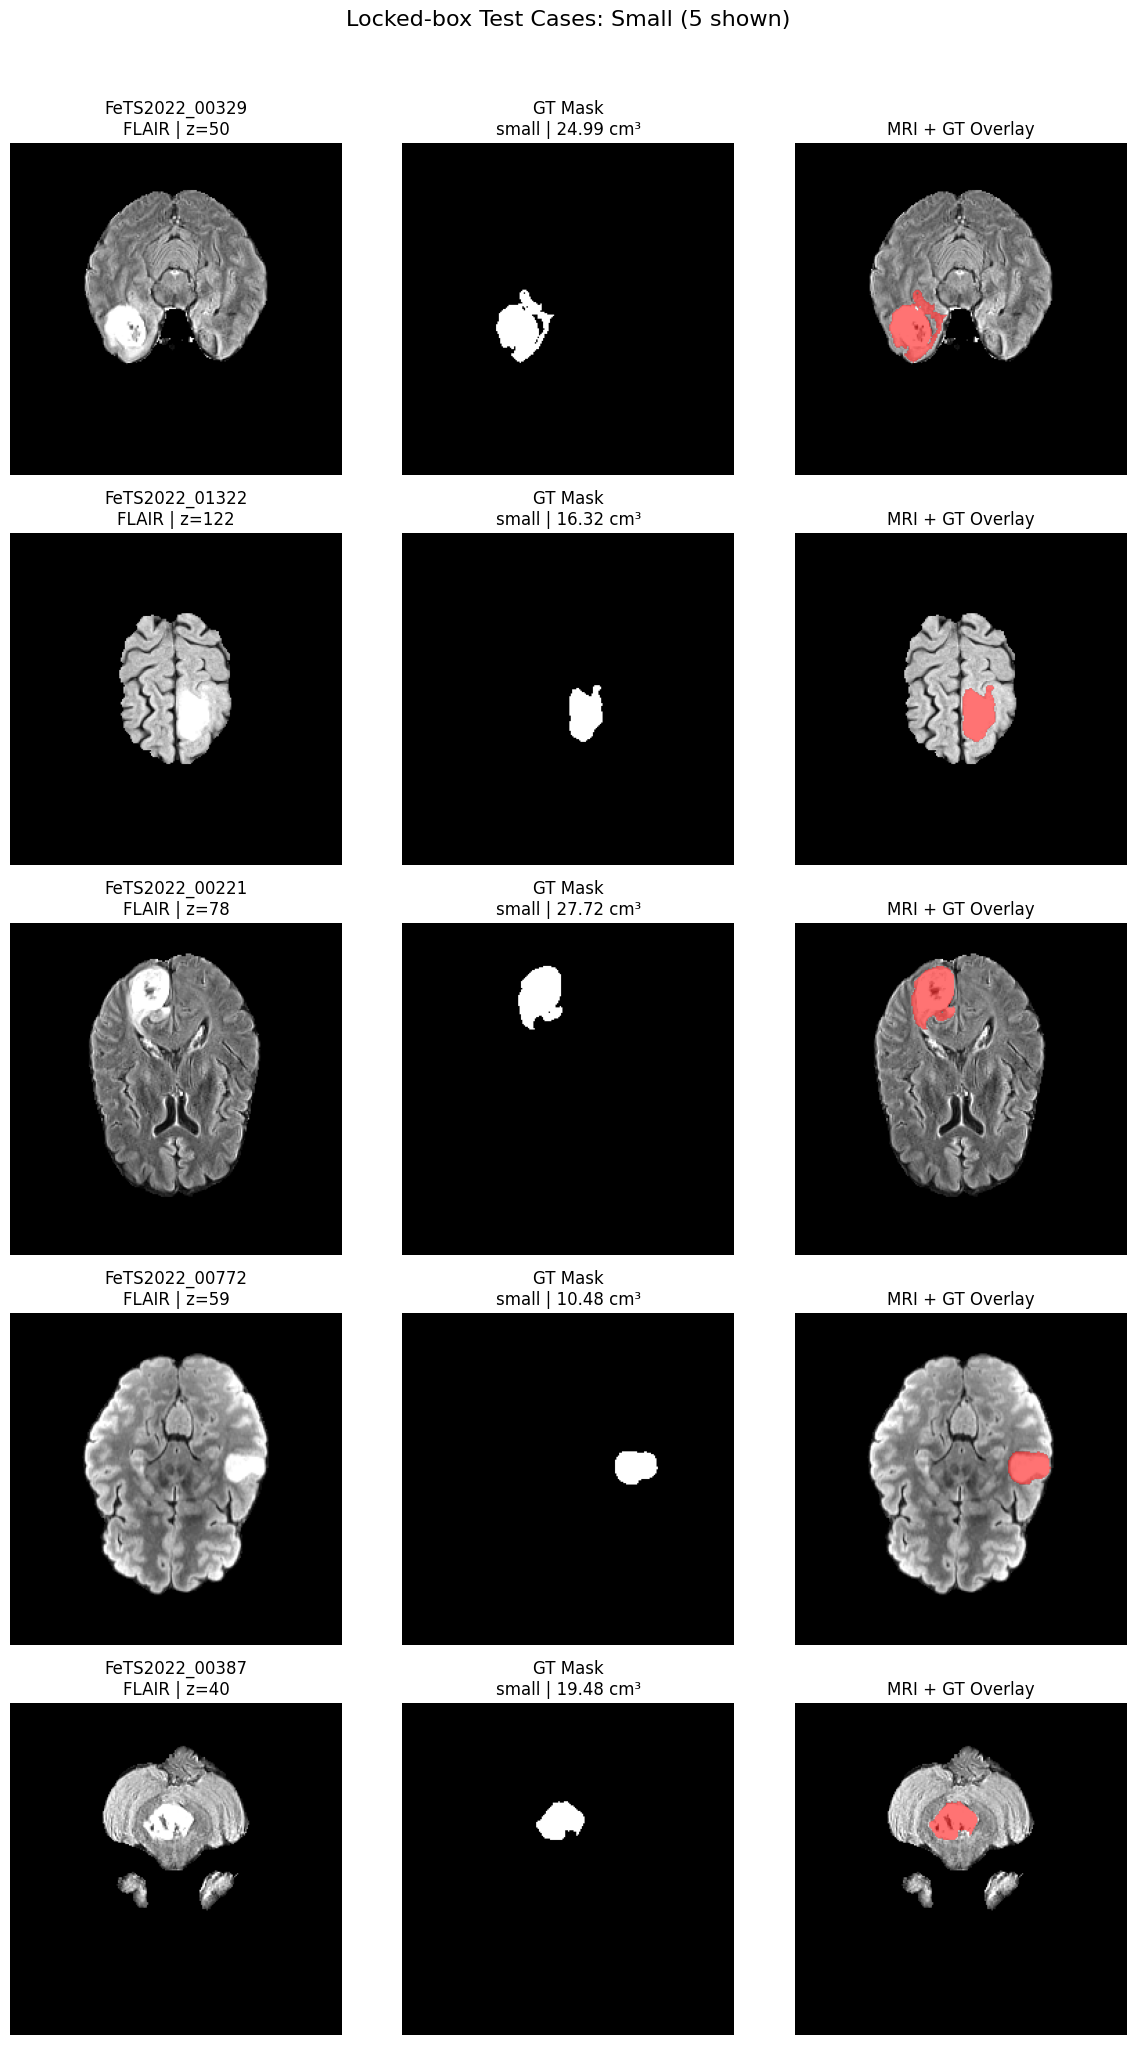

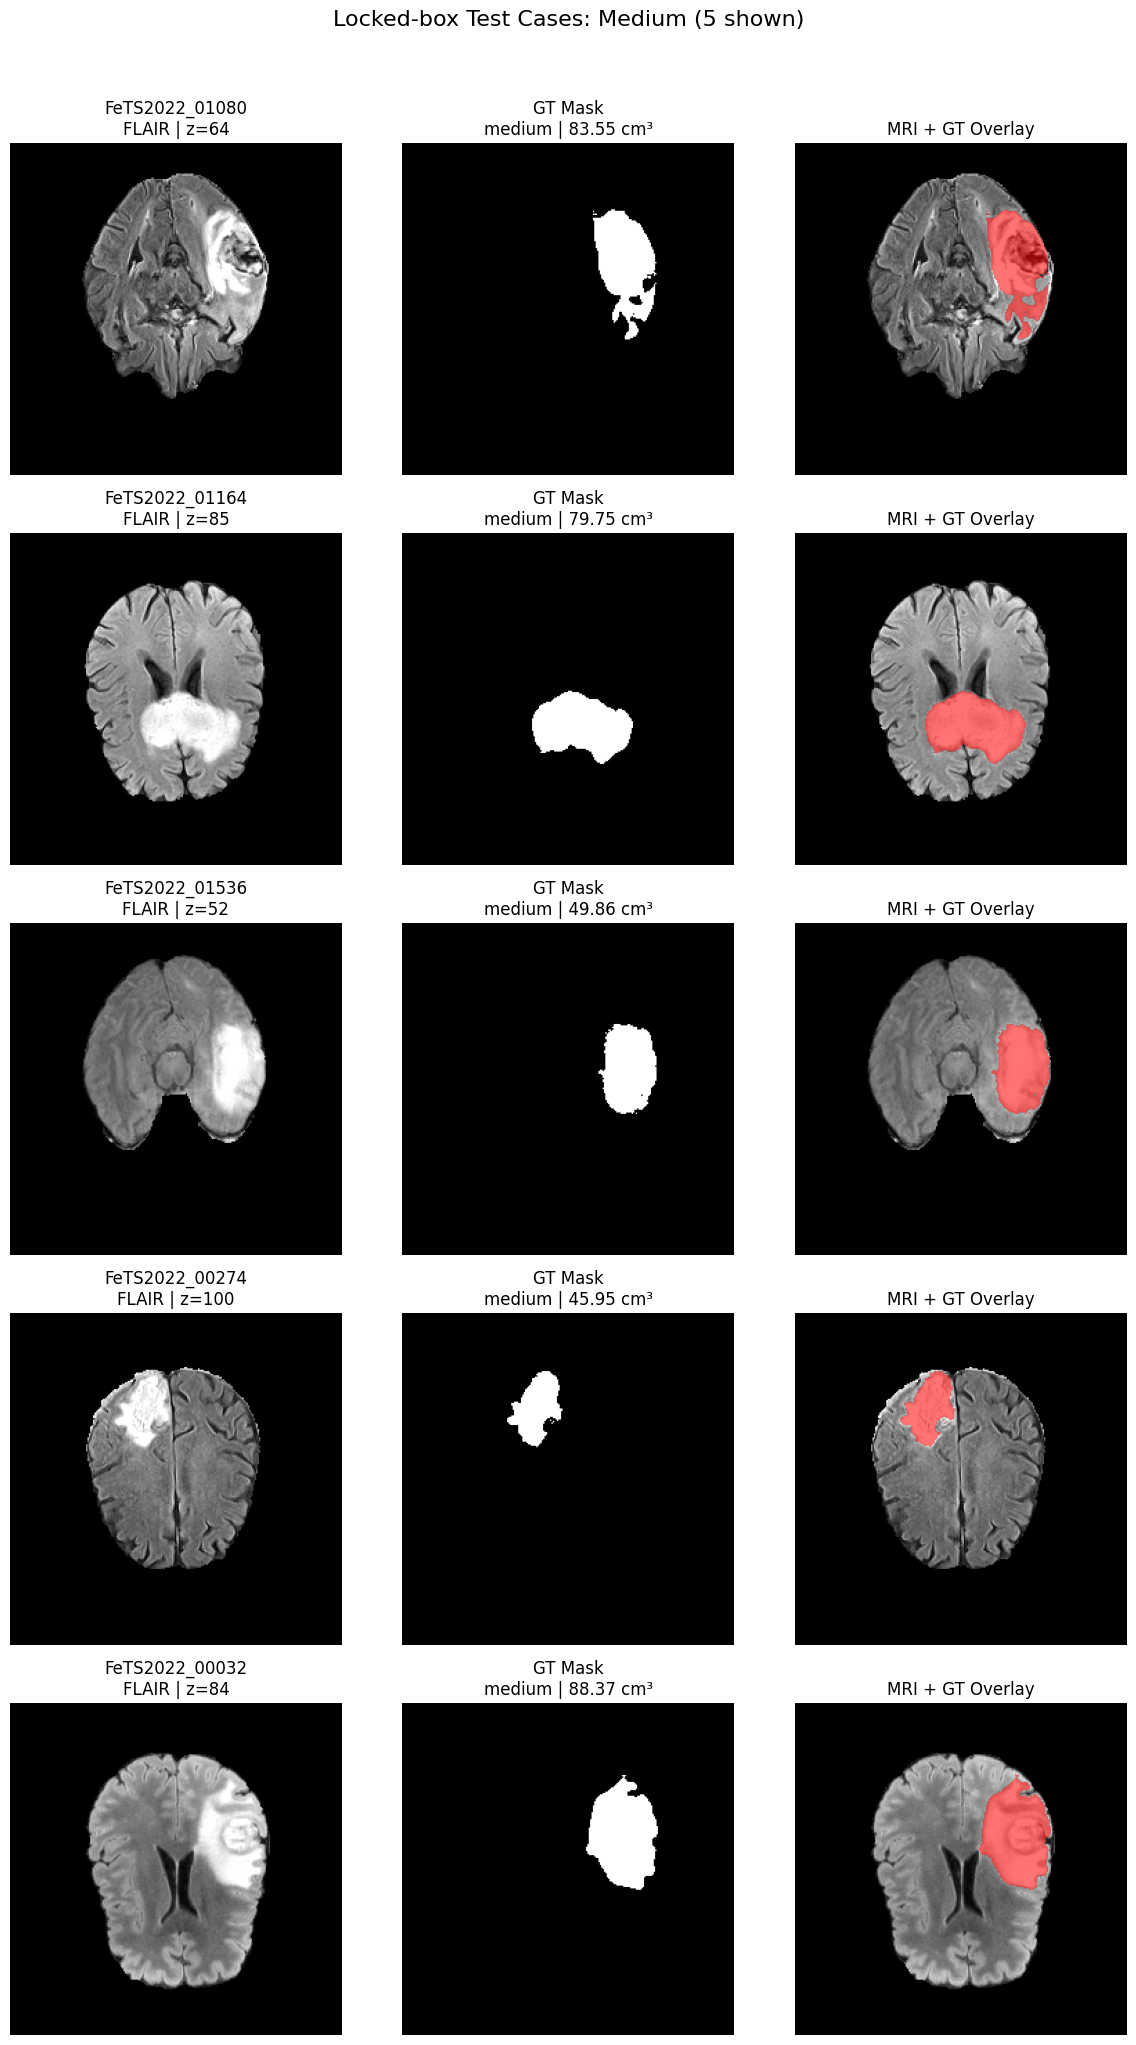

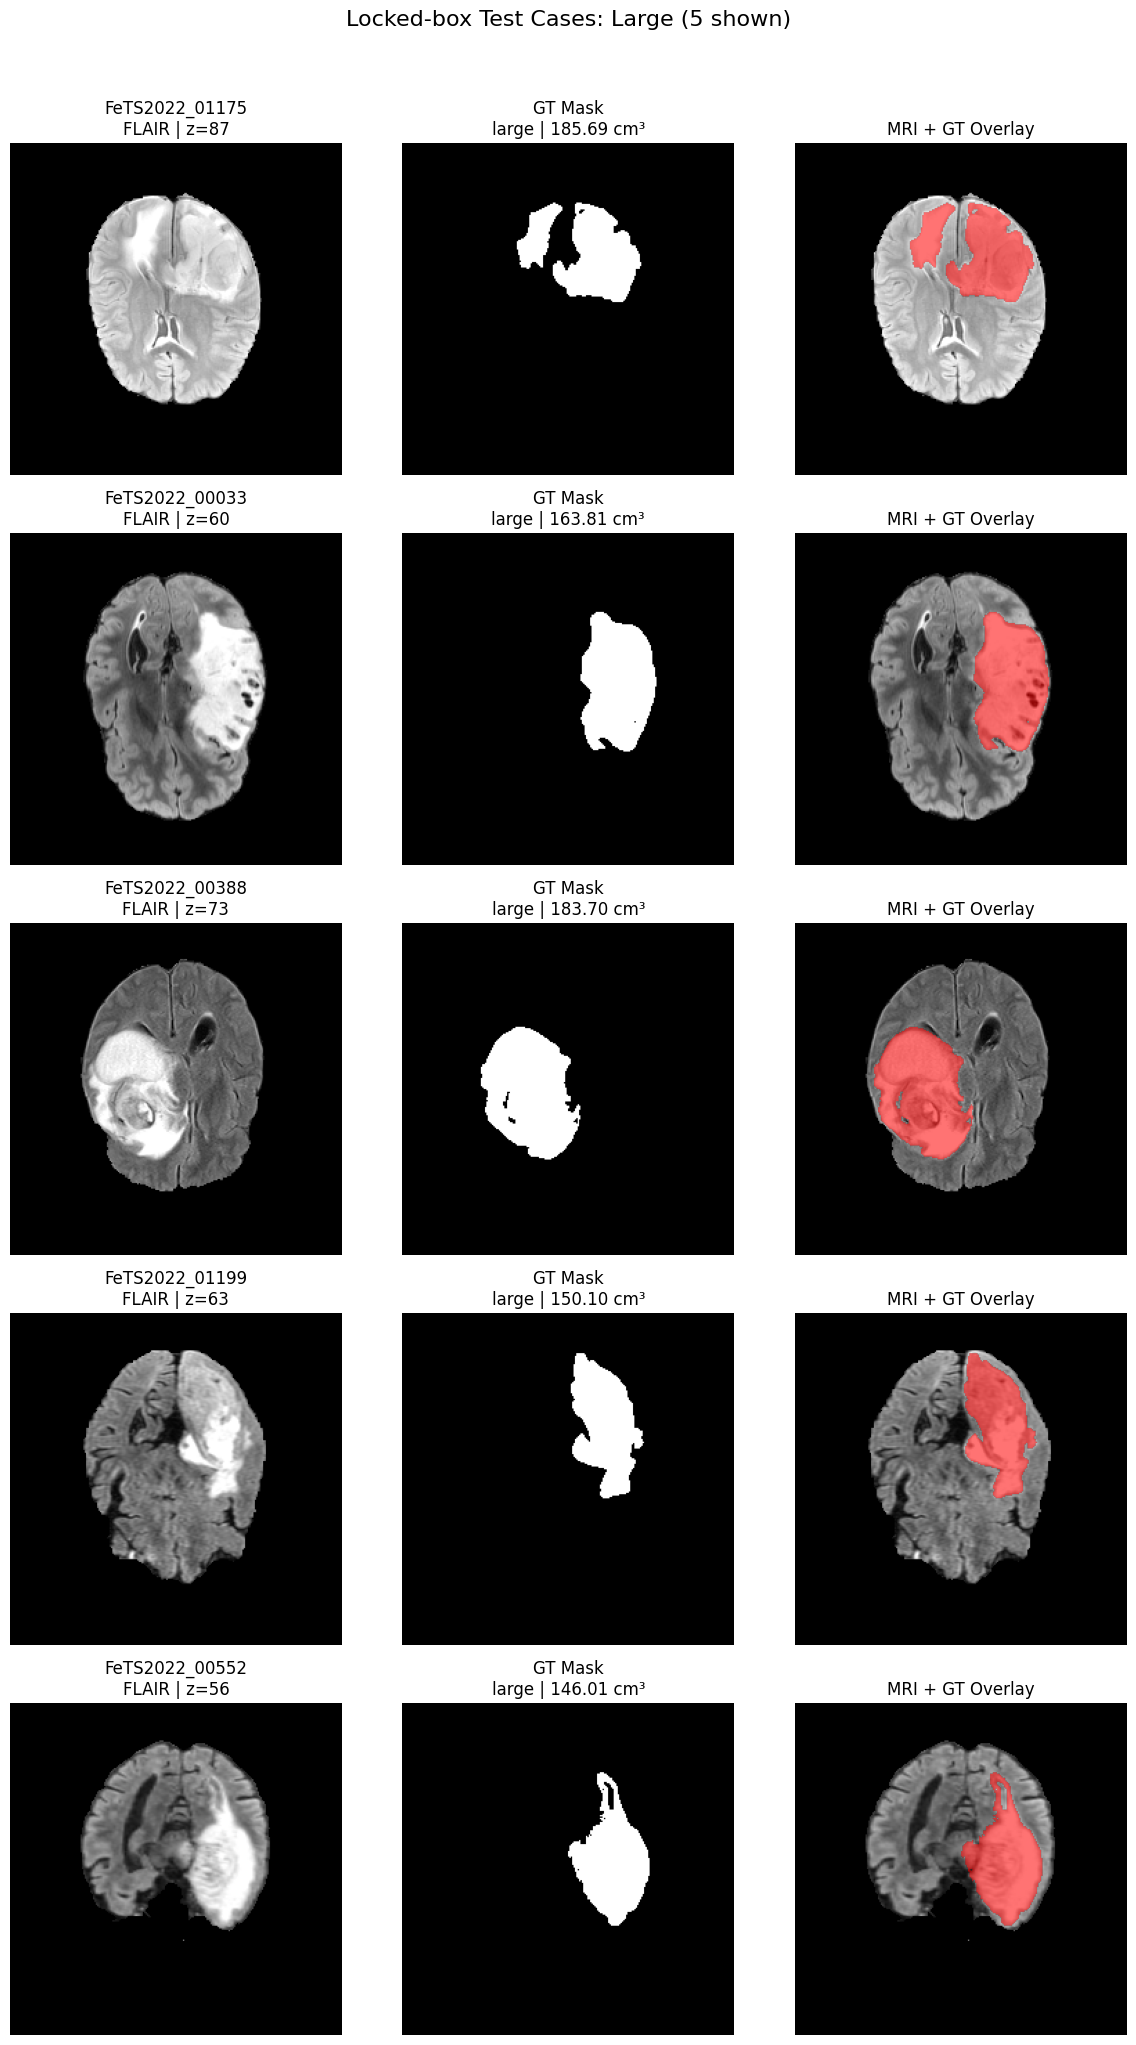

In [ ]:
# ===== visualize 5 locked-box test cases from each size group with GT masks =====

import random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

def _resolve_case_for_vis(case_path):
    case_path = Path(case_path)

    # use existing resolver if notebook already has it
    if "resolve_fets_files" in globals():
        img_paths, mask_path = resolve_fets_files(case_path)
        return img_paths, mask_path

    # fallback resolver
    files = list(case_path.glob("*.nii.gz"))
    flair = t1 = t1ce = t2 = seg = None

    for f in files:
        name = f.name.lower()
        if "seg" in name:
            seg = f
        elif "_flair" in name or "flair.nii.gz" in name:
            flair = f
        elif "_t1ce" in name or "t1ce.nii.gz" in name:
            t1ce = f
        elif ("_t1." in name or name.endswith("_t1.nii.gz") or "t1.nii.gz" in name) and "t1ce" not in name:
            t1 = f
        elif "_t2" in name or "t2.nii.gz" in name:
            t2 = f

    missing = []
    if flair is None: missing.append("flair")
    if t1 is None: missing.append("t1")
    if t1ce is None: missing.append("t1ce")
    if t2 is None: missing.append("t2")
    if seg is None: missing.append("seg")
    if missing:
        raise RuntimeError(f"{case_path.name}: missing {missing}")

    return [str(flair), str(t1), str(t1ce), str(t2)], str(seg)

def normalize_for_display(x):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip(x, lo, hi)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x

def show_test_group_examples(meta_rows, group_name, n_show=5):
    group_rows = [m for m in meta_rows if str(m["size_group"]).lower() == group_name.lower()]
    if len(group_rows) == 0:
        print(f"No test cases found for group: {group_name}")
        return

    chosen = random.sample(group_rows, min(n_show, len(group_rows)))

    fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    fig.suptitle(f"Locked-box Test Cases: {group_name.capitalize()} ({len(chosen)} shown)", fontsize=16, y=1.02)

    for i, meta in enumerate(chosen):
        case_path = Path(meta["case_path"])
        case_name = str(meta.get("case_name", case_path.name))
        lesion_cm3 = float(meta.get("lesion_cm3", np.nan))

        img_paths, mask_path = _resolve_case_for_vis(case_path)

        # show FLAIR
        flair = nib.load(str(img_paths[0])).get_fdata().astype(np.float32)
        mask = (nib.load(str(mask_path)).get_fdata() > 0).astype(np.uint8)

        if mask.sum() > 0:
            z = int(np.argmax(mask.sum(axis=(0, 1))))
        else:
            z = flair.shape[2] // 2

        img_slice = normalize_for_display(flair[:, :, z])
        mask_slice = mask[:, :, z]

        # MRI only
        axes[i, 0].imshow(img_slice.T, cmap="gray", origin="lower")
        axes[i, 0].set_title(f"{case_name}\nFLAIR | z={z}")
        axes[i, 0].axis("off")

        # GT only
        axes[i, 1].imshow(mask_slice.T, cmap="gray", origin="lower")
        axes[i, 1].set_title(f"GT Mask\n{group_name} | {lesion_cm3:.2f} cm³")
        axes[i, 1].axis("off")

        # overlay
        axes[i, 2].imshow(img_slice.T, cmap="gray", origin="lower")
        axes[i, 2].imshow(
            np.ma.masked_where(mask_slice.T == 0, mask_slice.T),
            cmap="autumn",
            alpha=0.55,
            origin="lower"
        )
        axes[i, 2].set_title("MRI + GT Overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Use existing test metadata from notebook
for grp in ["small", "medium", "large"]:
    show_test_group_examples(test_meta, grp, n_show=5)

In [ ]:
# ===== inspect saved LADS checkpoints =====

from pathlib import Path

lads_exp_dir = OUTPUT_DIR / "fedprox_lads"
lads_ckpt_dir = lads_exp_dir / "checkpoints"

print("Experiment dir:", lads_exp_dir)
print("Checkpoint dir:", lads_ckpt_dir)

if not lads_ckpt_dir.exists():
    raise FileNotFoundError(f"Checkpoint directory not found: {lads_ckpt_dir}")

ckpts = sorted(lads_ckpt_dir.glob("fedprox_lads*.pt"))
print(f"Found {len(ckpts)} checkpoint file(s):")
for p in ckpts:
    print(" -", p.name)

Experiment dir: /content/drive/MyDrive/fets_lads_outputs/fedprox_lads
Checkpoint dir: /content/drive/MyDrive/fets_lads_outputs/fedprox_lads/checkpoints
Found 4 checkpoint file(s):
 - fedprox_lads_best.pt
 - fedprox_lads_last.pt
 - fedprox_lads_round_1.pt
 - fedprox_lads_round_2.pt


Loaded history from: /content/drive/MyDrive/fets_lads_outputs/fedprox_lads/fedprox_lads_history.csv


,round,val_mean_dice,val_worst_client_dice,val_small_dice_mean,val_medium_dice_mean,val_large_dice_mean,val_fairness_gap,val_eval_mode
0,1,0.135038,0.070205,0.027609,0.068194,0.164091,0.064833,full
1,2,0.225838,0.076127,0.043131,0.101074,0.347574,0.149711,fast_subset
2,3,0.277678,0.093380,0.051122,0.127377,0.429789,0.184297,fast_subset
3,4,0.309767,0.105893,0.057095,0.146427,0.479969,0.203874,fast_subset
4,5,0.350307,0.183411,0.060422,0.178214,0.421203,0.166896,full


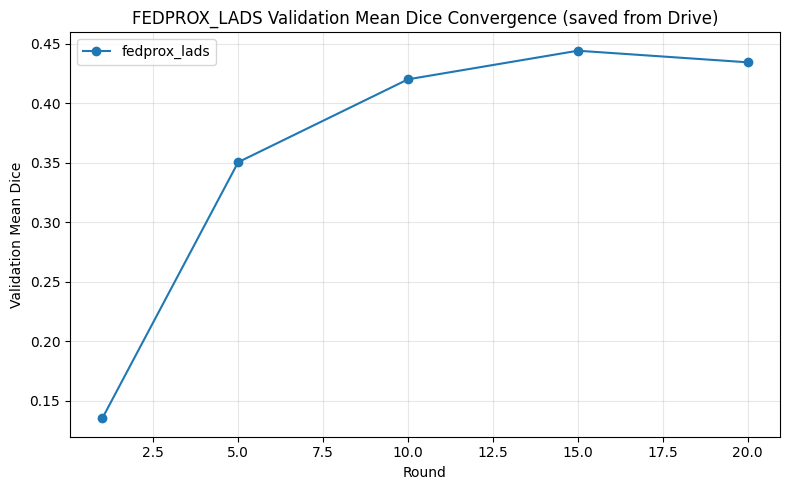

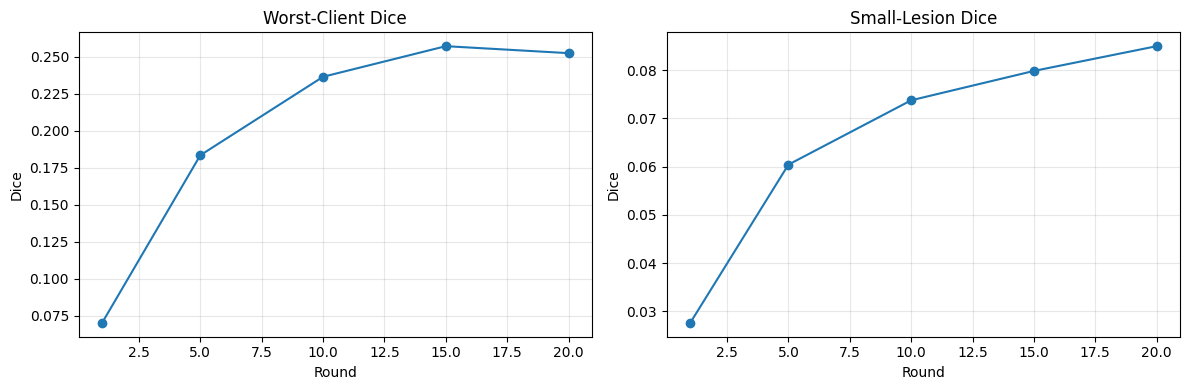


Loaded final locked-box test metrics from: /content/drive/MyDrive/fets_lads_outputs/fedprox_lads/fedprox_lads_locked_box_test_metrics.csv


,mean_dice,small_dice,medium_dice,large_dice,n_cases,fairness_gap,small_lesion_gap
0,0.338158,0.087527,0.326029,0.600918,90,0.314086,0.250631



Loaded difficulty history from: /content/drive/MyDrive/fets_lads_outputs/fedprox_lads/fedprox_lads_difficulty_history.csv


,round,client_id,lambda_lft,agg_weight,prox_mu,last_local_epoch_loss,last_epoch_positive_patch_rate,hardship_eval_this_round,mean_dice,small_dice,medium_dice,large_dice,n_cases,fairness_gap,small_lesion_gap,frac_small,hardship_gap,hardship
0,1,0,0.150000,70.000000,0.01,0.802769,0.996429,True,0.079438,NaN,NaN,0.079438,4,0.022168,NaN,0.0,0.000000,0.000000
1,1,1,0.150000,70.000000,0.01,0.951248,0.978571,True,0.038981,NaN,0.030697,0.063834,4,0.014228,NaN,0.0,0.000000,0.000000
2,1,2,0.150000,70.000000,0.01,0.802757,1.000000,True,0.084935,NaN,NaN,0.084935,4,0.015147,NaN,0.0,0.000000,0.000000
3,1,3,0.150000,45.000000,0.01,0.888473,0.994565,True,0.072321,NaN,0.023254,0.088676,4,0.049067,NaN,0.0,0.000000,0.000000
4,1,4,0.171258,69.586723,0.01,0.848034,1.000000,True,0.041682,0.013338,0.037794,0.102258,4,0.030499,0.028344,0.5,0.028344,0.014172


In [ ]:
# ===== load saved LADS metrics from Drive only (no recomputation) =====

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

lads_exp_dir = OUTPUT_DIR / "fedprox_lads"

history_csv = lads_exp_dir / "fedprox_lads_history.csv"
test_csv    = lads_exp_dir / "fedprox_lads_locked_box_test_metrics.csv"
diff_csv    = lads_exp_dir / "fedprox_lads_difficulty_history.csv"

if not history_csv.exists():
    raise FileNotFoundError(f"Missing history CSV: {history_csv}")

history_df = pd.read_csv(history_csv)
print("Loaded history from:", history_csv)
display(history_df.head())

# If you want only full-validation rounds:
full_df = history_df[history_df["val_eval_mode"] == "full"].copy()
if len(full_df) == 0:
    full_df = history_df.copy()

# ---- Plot overall validation mean Dice convergence ----
plt.figure(figsize=(8, 5))
plt.plot(full_df["round"], full_df["val_mean_dice"], marker="o", label="fedprox_lads")
plt.xlabel("Round")
plt.ylabel("Validation Mean Dice")
plt.title("FEDPROX_LADS Validation Mean Dice Convergence (saved from Drive)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Optional: plot worst-client and small-lesion too ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(full_df["round"], full_df["val_worst_client_dice"], marker="o")
axes[0].set_title("Worst-Client Dice")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Dice")
axes[0].grid(True, alpha=0.3)

axes[1].plot(full_df["round"], full_df["val_small_dice_mean"], marker="o")
axes[1].set_title("Small-Lesion Dice")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Dice")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Load final locked-box test metrics if available ----
if test_csv.exists():
    test_df = pd.read_csv(test_csv)
    print("\nLoaded final locked-box test metrics from:", test_csv)
    display(test_df)
else:
    print("\nNo locked-box test metrics CSV found.")

# ---- Load difficulty history if available ----
if diff_csv.exists():
    difficulty_df = pd.read_csv(diff_csv)
    print("\nLoaded difficulty history from:", diff_csv)
    display(difficulty_df.head())
else:
    print("\nNo difficulty history CSV found.")

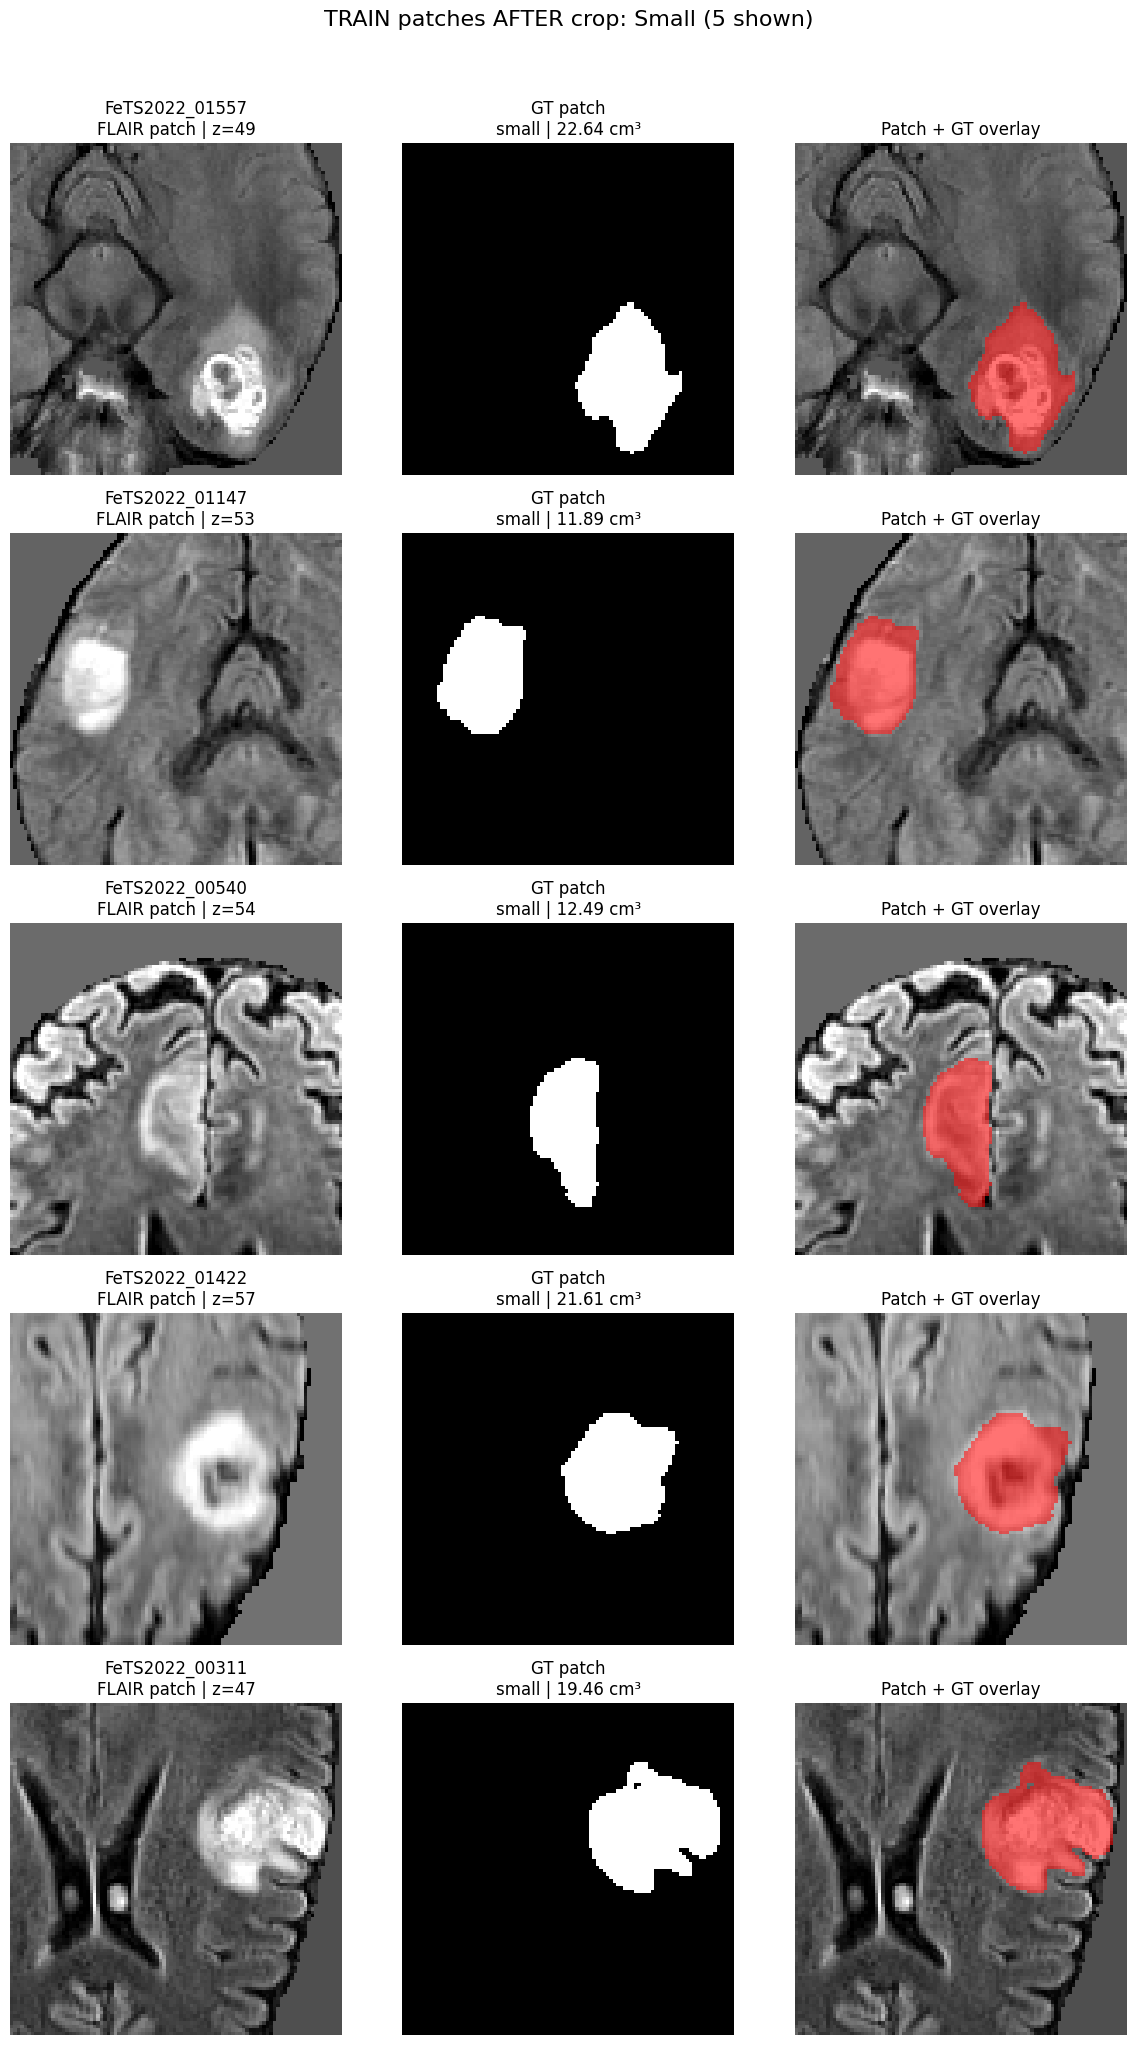

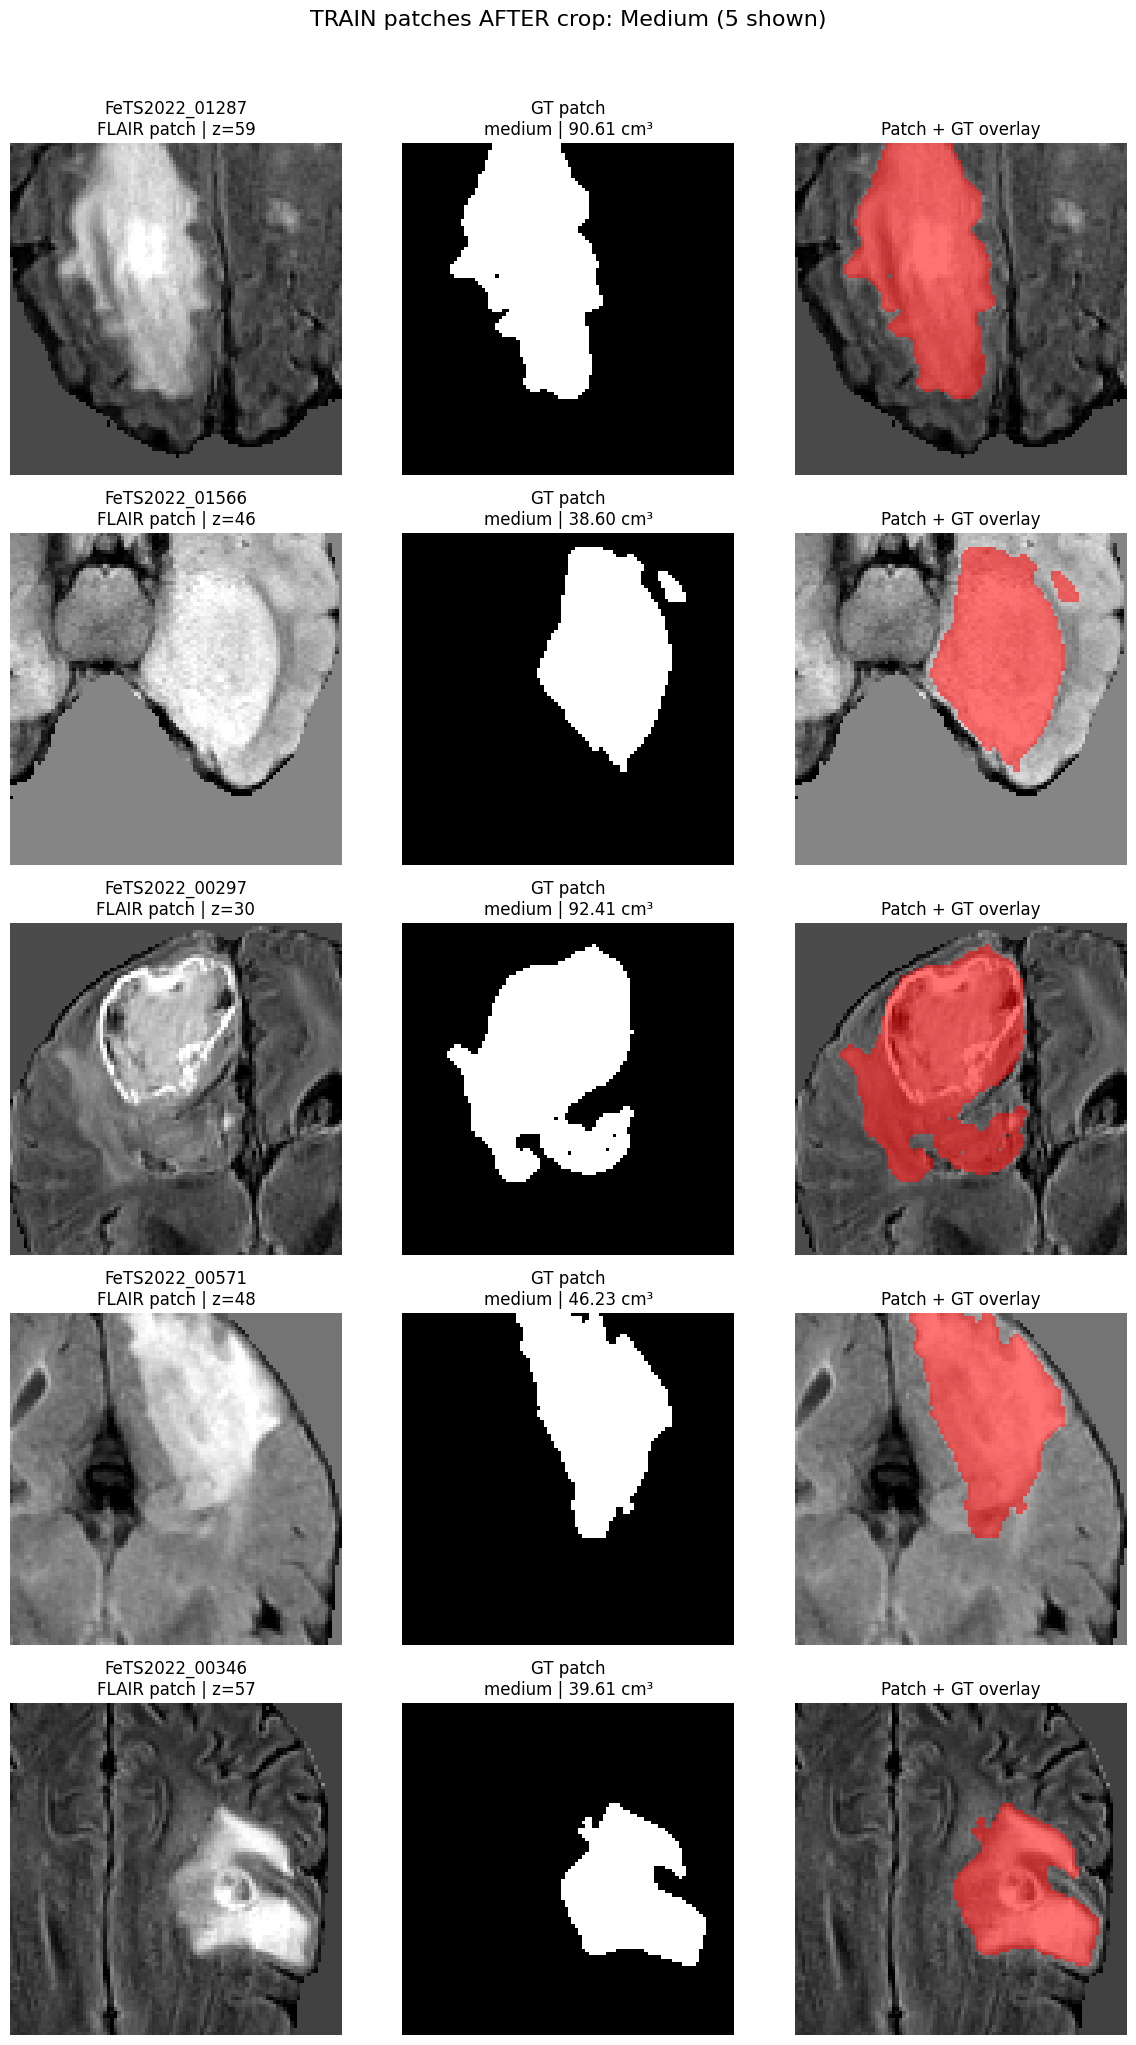

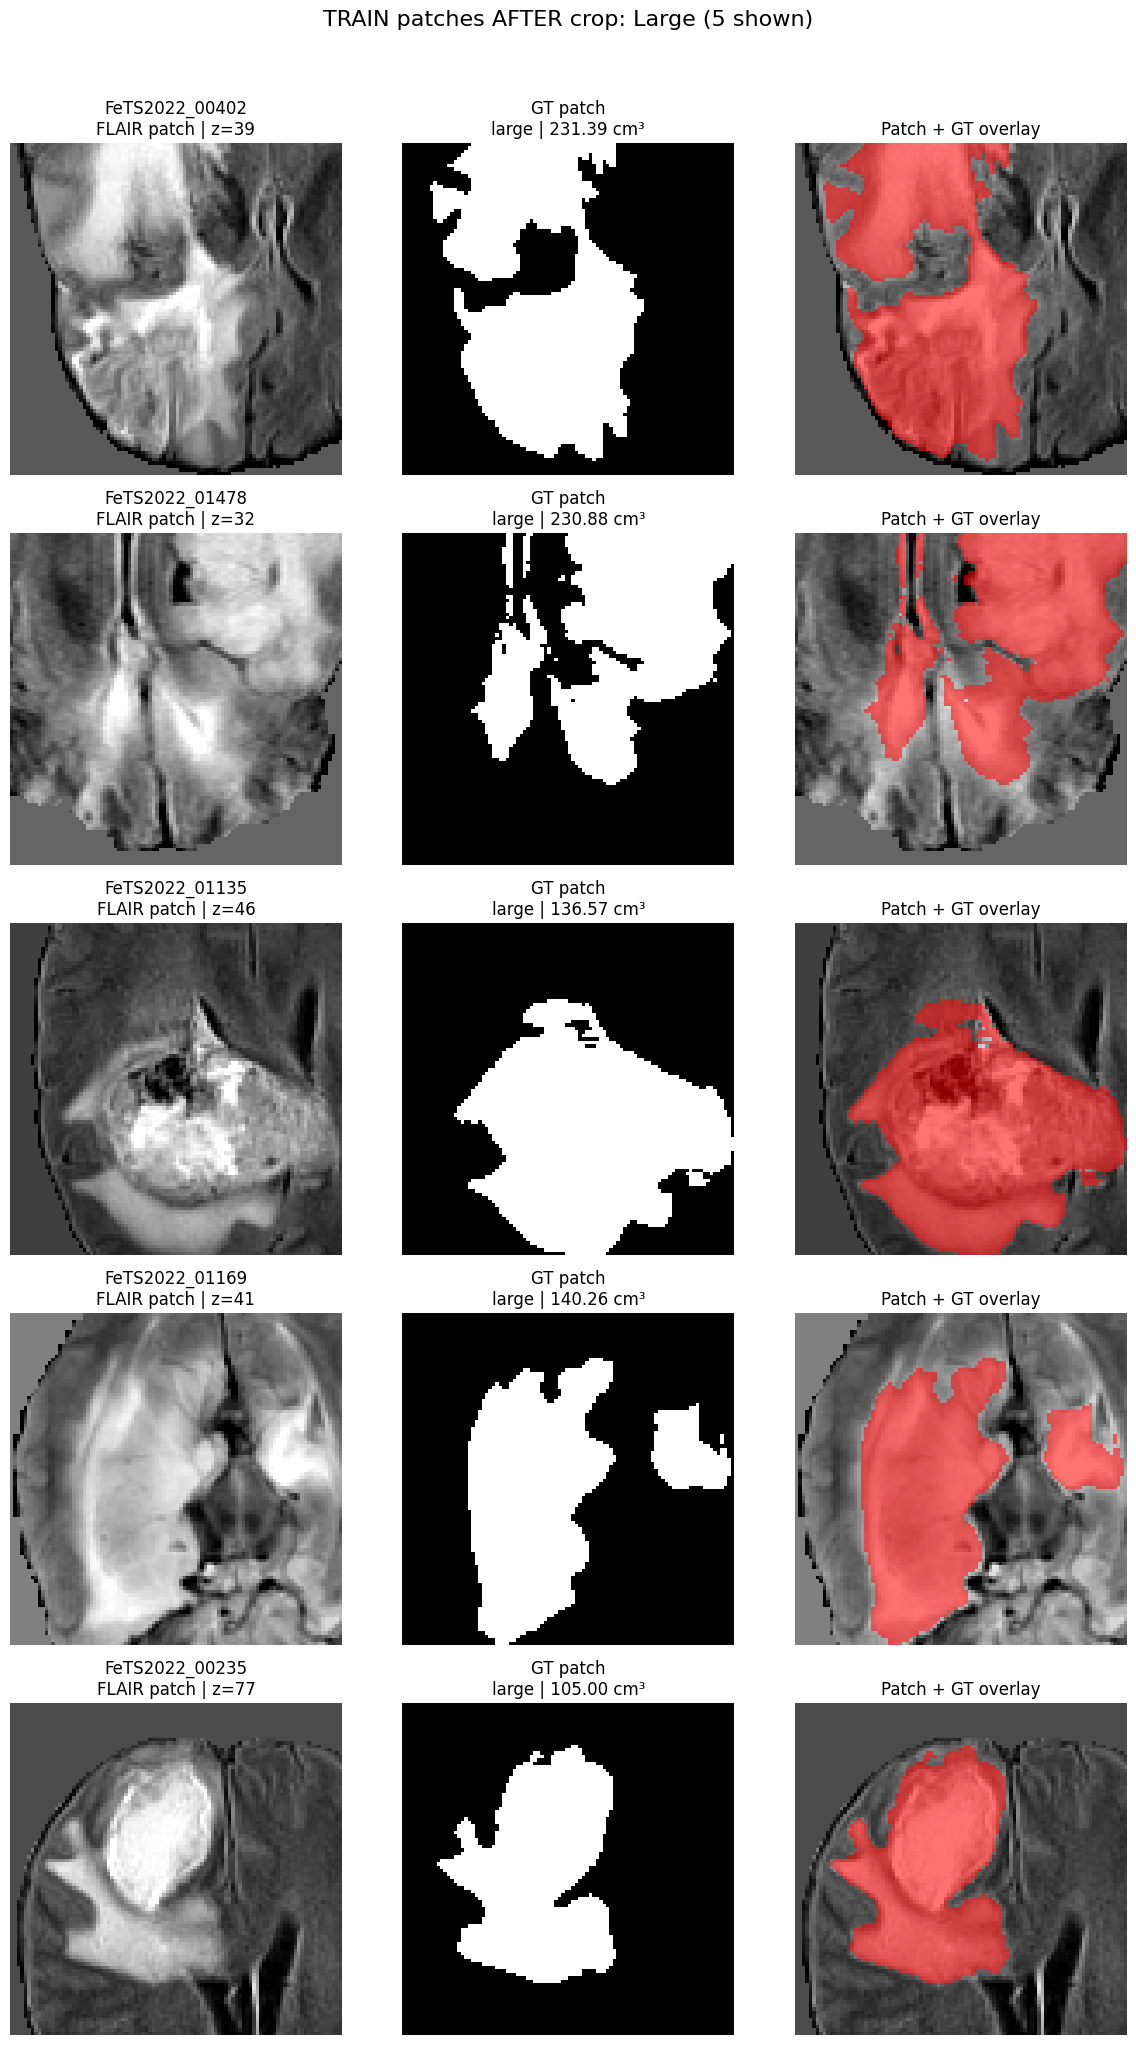

In [ ]:
# ===== visualize 5 TRAIN MRI patches of each lesion size AFTER crop =====

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    ConcatItemsd, DeleteItemsd, CropForegroundd, SpatialPadd,
    RandCropByPosNegLabeld, ToTensord
)

random.seed(42)
np.random.seed(42)

# ---- gather all train metadata rows across clients ----
all_train_meta = [row for client_rows in train_meta_by_client for row in client_rows]

if len(all_train_meta) == 0:
    raise RuntimeError("train_meta_by_client is empty.")

# ---- helper: resolve case files robustly ----
def _resolve_case_for_vis(case_path):
    case_path = Path(case_path)

    if "resolve_fets_files" in globals():
        img_paths, mask_path = resolve_fets_files(case_path)
        return {
            "flair": str(img_paths[0]),
            "t1": str(img_paths[1]),
            "t1ce": str(img_paths[2]),
            "t2": str(img_paths[3]),
            "label": str(mask_path),
        }

    # fallback resolver
    files = list(case_path.glob("*.nii.gz"))
    flair = t1 = t1ce = t2 = seg = None

    for f in files:
        name = f.name.lower()
        if "seg" in name:
            seg = f
        elif "_flair" in name or "flair.nii.gz" in name:
            flair = f
        elif "_t1ce" in name or "t1ce.nii.gz" in name:
            t1ce = f
        elif ("_t1." in name or name.endswith("_t1.nii.gz") or "t1.nii.gz" in name) and "t1ce" not in name:
            t1 = f
        elif "_t2" in name or "t2.nii.gz" in name:
            t2 = f

    missing = []
    if flair is None: missing.append("flair")
    if t1 is None: missing.append("t1")
    if t1ce is None: missing.append("t1ce")
    if t2 is None: missing.append("t2")
    if seg is None: missing.append("seg")
    if missing:
        raise RuntimeError(f"{case_path.name}: missing {missing}")

    return {
        "flair": str(flair),
        "t1": str(t1),
        "t1ce": str(t1ce),
        "t2": str(t2),
        "label": str(seg),
    }

# ---- visualization transform: same crop stage, no augmentations ----
vis_crop_transform = Compose([
    LoadImaged(keys=["flair", "t1", "t1ce", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t1ce", "t2", "label"]),
    NormalizeIntensityd(keys=["flair", "t1", "t1ce", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t1ce", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t1ce", "t2"]),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=ROI_SIZE),
    # force a positive crop so you can inspect lesion-containing patches
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=1,
        neg=0,
        num_samples=1,
        image_key="image",
        image_threshold=0.0,
    ),
    ToTensord(keys=["image", "label"]),
])

def _normalize_for_display(x):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip(x, lo, hi)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x

def _show_group_after_crop(group_name, n_show=5):
    rows = [r for r in all_train_meta if str(r["size_group"]).lower() == group_name.lower()]
    if len(rows) == 0:
        print(f"No TRAIN cases found for group: {group_name}")
        return

    chosen = random.sample(rows, min(n_show, len(rows)))

    fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    fig.suptitle(f"TRAIN patches AFTER crop: {group_name.capitalize()} ({len(chosen)} shown)", fontsize=16, y=1.02)

    for i, meta in enumerate(chosen):
        rec = _resolve_case_for_vis(meta["case_path"])
        out = vis_crop_transform(rec)

        # RandCropByPosNegLabeld with num_samples=1 may return a list
        if isinstance(out, list):
            out = out[0]

        img = out["image"].cpu().numpy()   # [4, H, W, D]
        lbl = out["label"].cpu().numpy()   # [1, H, W, D]

        flair = img[0]
        mask = (lbl[0] > 0).astype(np.uint8)

        # choose slice with maximum tumor area
        if mask.sum() > 0:
            z = int(np.argmax(mask.sum(axis=(0, 1))))
        else:
            z = flair.shape[2] // 2

        img_slice = _normalize_for_display(flair[:, :, z])
        mask_slice = mask[:, :, z]

        case_name = str(meta.get("case_name", Path(meta["case_path"]).name))
        lesion_cm3 = float(meta.get("lesion_cm3", np.nan))

        axes[i, 0].imshow(img_slice.T, cmap="gray", origin="lower")
        axes[i, 0].set_title(f"{case_name}\nFLAIR patch | z={z}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_slice.T, cmap="gray", origin="lower")
        axes[i, 1].set_title(f"GT patch\n{group_name} | {lesion_cm3:.2f} cm³")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img_slice.T, cmap="gray", origin="lower")
        axes[i, 2].imshow(
            np.ma.masked_where(mask_slice.T == 0, mask_slice.T),
            cmap="autumn",
            alpha=0.55,
            origin="lower",
        )
        axes[i, 2].set_title("Patch + GT overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

for grp in ["small", "medium", "large"]:
    _show_group_after_crop(grp, n_show=5)